## SECTION 1 — Setup & Install Dependencies

In [ ]:
!pip uninstall -y jax jaxlib opencv-python opencv-python-headless opencv-contrib-python cupy-cuda12x shap

Found existing installation: opencv-python-headless 4.10.0.84
Uninstalling opencv-python-headless-4.10.0.84:
  Successfully uninstalled opencv-python-headless-4.10.0.84


In [ ]:
!pip install -q --no-cache-dir \
torch==2.2.2 \
torchvision==0.17.2 \
torchaudio==2.2.2 \
transformers==4.41.2 \
datasets==2.19.1 \
accelerate==0.30.1 \
peft==0.11.1 \
evaluate==0.4.2 \
jiwer==3.0.3 \
numpy==1.26.4 \
pandas==2.2.2 \
librosa==0.10.2 \
soundfile==0.12.1 \
sentencepiece \
pydub \
openpyxl \
requests==2.32.4 \
tqdm \
opencv-python-headless==4.10.0.84

!apt-get install -q -y ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 369.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [ ]:
import os
import re
import json
import requests
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from tqdm import tqdm
from pathlib import Path
from pydub import AudioSegment

import torch
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    WhisperFeatureExtractor,
    WhisperTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
from datasets import Dataset, Audio, load_dataset
import evaluate
from dataclasses import dataclass
from typing import Any, Dict, List, Union

# Output directories
os.makedirs('/content/audio_files', exist_ok=True)
os.makedirs('/content/transcription_files', exist_ok=True)
os.makedirs('/content/segments', exist_ok=True)
os.makedirs('/content/model_output', exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Using device: cuda


## SECTION 2 — Load Excel & Fix URLs

In [ ]:
def fix_url(old_url):
    try:
        if pd.isna(old_url) or not isinstance(old_url, str):
            return None
        parts = old_url.strip().split('/')
        folder_id = parts[-2]
        file_name = parts[-1]
        return f'https://storage.googleapis.com/upload_goai/{folder_id}/{file_name}'
    except Exception:
        return None

df['rec_url_gcp']           = df['rec_url_gcp'].apply(fix_url)
df['transcription_url_gcp'] = df['transcription_url_gcp'].apply(fix_url)
df['metadata_url_gcp']      = df['metadata_url_gcp'].apply(fix_url)

df = df.dropna(subset=['rec_url_gcp', 'transcription_url_gcp'])
df = df.reset_index(drop=True)
print(f'Valid rows after URL fix: {len(df)}')

Valid rows after URL fix: 104


## SECTION 3 — Download Audio & Transcription Files

In [ ]:
def download_file(url, dest_path, timeout=30):
    """Download a file from a URL. Returns True on success."""
    try:
        if not url:
            return False
        r = requests.get(url, timeout=timeout, stream=True)
        if r.status_code == 200:
            with open(dest_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            return True
        return False
    except Exception as e:
        return False

audio_paths         = []
transcription_paths = []
valid_indices       = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Downloading files'):
    rid = str(row['recording_id'])

    audio_ext  = os.path.splitext(row['rec_url_gcp'])[-1] or '.wav'
    audio_path = f'/content/audio_files/{rid}{audio_ext}'
    audio_ok   = download_file(row['rec_url_gcp'], audio_path)

    trans_path = f'/content/transcription_files/{rid}.json'
    trans_ok   = download_file(row['transcription_url_gcp'], trans_path)

    if audio_ok and trans_ok:
        audio_paths.append(audio_path)
        transcription_paths.append(trans_path)
        valid_indices.append(idx)

df_valid = df.loc[valid_indices].copy().reset_index(drop=True)
df_valid['audio_path']         = audio_paths
df_valid['transcription_path'] = transcription_paths
print(f'Successfully downloaded: {len(df_valid)} / {len(df)} rows')

Successfully downloaded: 104 / 104 rows


## SECTION 4 — Parse Transcription JSON & Build Structured Dataset

In [ ]:
def parse_transcription(json_path):
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        segments = []
        full_text = ""

        if isinstance(data, list):
            for seg in data:
                if isinstance(seg, dict) and "text" in seg:
                    text = seg["text"]
                    start = seg.get("start", None)
                    end = seg.get("end", None)

                    if text:
                        full_text += " " + text

                    if start is not None and end is not None:
                        segments.append({
                            "start": float(start),
                            "end": float(end),
                            "text": text
                        })

        elif isinstance(data, dict):
            full_text = data.get("text", "") or data.get("transcription", "")

        return full_text.strip(), segments

    except Exception as e:
        print(f"Error parsing {json_path}: {e}")
        return "", []



def clean_hindi_text(text):
    """Normalize Hindi text: remove non-Devanagari noise, normalize spaces."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^\u0900-\u097F\u0020-\u007Ea-zA-Z0-9\s।,\.!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


rows = []
all_segments_raw = []

for idx, row in df_valid.iterrows():
    text, segments = parse_transcription(row['transcription_path'])
    clean_text = clean_hindi_text(text)
    if clean_text:
        rows.append({
            'recording_id': row['recording_id'],
            'audio_path':   row['audio_path'],
            'sentence':     clean_text,
            'duration':     row.get('duration', None),
        })
        all_segments_raw.append({
            'recording_id':  row['recording_id'],
            'audio_path':    row['audio_path'],
            'full_text':     clean_text,
            'raw_text':      text,
            'segments':      segments,
        })

df_processed = pd.DataFrame(rows)
print(f'Processed records: {len(df_processed)}')
df_processed.head()

Processed records: 104


,recording_id,audio_path,sentence,duration
0,825780,/content/audio_files/825780.wav,अब काफी अच्छा होता है क्योंकि उनकी जनसंख्या बह...,443
1,825727,/content/audio_files/825727.wav,जी जी जी जी जी । जी जी जी हां उधर हां जी हा हा...,443
2,988596,/content/audio_files/988596.wav,लेकिन हम लोग इसे छुपछुप के लोगों के घर जाकर खे...,475
3,990175,/content/audio_files/990175.wav,जी जी जी जी जी मेरे तो जैसे बहुत सारी यादे हैं...,475
4,526266,/content/audio_files/526266.wav,हां जी पहले बात करते हैं विवाह की तो इस मुवी म...,522


## SECTION 5 — Convert Audio to 16 kHz WAV & Build HuggingFace Dataset

In [ ]:
TARGET_SR = 16000

def convert_to_wav16k(src_path, dest_path):
    """Load any audio file and resave as 16-kHz mono WAV."""
    try:
        audio, sr = librosa.load(src_path, sr=TARGET_SR, mono=True)
        sf.write(dest_path, audio, TARGET_SR)
        return dest_path
    except Exception as e:
        print(f'  Conversion failed for {src_path}: {e}')
        return None

wav16k_paths = []
valid_mask   = []

for _, row in tqdm(df_processed.iterrows(), total=len(df_processed), desc='Converting audio'):
    rid      = str(row['recording_id'])
    out_path = f'/content/audio_files/{rid}_16k.wav'
    result   = convert_to_wav16k(row['audio_path'], out_path)
    wav16k_paths.append(result)
    valid_mask.append(result is not None)

df_processed['wav_path'] = wav16k_paths
df_processed = df_processed[valid_mask].reset_index(drop=True)

seg_idx = 0
updated_segments_raw = []
for i, ok in enumerate(valid_mask):
    if ok and seg_idx < len(all_segments_raw):
        all_segments_raw[seg_idx]['wav_path'] = wav16k_paths[i]
        updated_segments_raw.append(all_segments_raw[seg_idx])
    seg_idx += 1
all_segments_raw = updated_segments_raw

print(f'Audio ready: {len(df_processed)} records')

Converting audio: 100%|██████████| 104/104 [01:11<00:00,  1.46it/s]

Audio ready: 104 records


In [ ]:
hf_dataset = Dataset.from_dict({
    'audio':    df_processed['wav_path'].tolist(),
    'sentence': df_processed['sentence'].tolist(),
})
hf_dataset = hf_dataset.cast_column('audio', Audio(sampling_rate=TARGET_SR))
print(hf_dataset)

split       = hf_dataset.train_test_split(test_size=0.1, seed=42)
train_data  = split['train']
test_data   = split['test']
print(f'Train: {len(train_data)} | Test: {len(test_data)}')

Dataset({
    features: ['audio', 'sentence'],
    num_rows: 104
})
Train: 93 | Test: 11


## SECTION 6 — Load Whisper-Small & Prepare Feature Extractor / Tokenizer

In [ ]:
MODEL_ID = 'openai/whisper-small'

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_ID)
tokenizer         = WhisperTokenizer.from_pretrained(MODEL_ID, language='Hindi', task='transcribe')
processor         = WhisperProcessor.from_pretrained(MODEL_ID,  language='Hindi', task='transcribe')

print('Whisper-small processor loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Whisper-small processor loaded.


In [ ]:
def prepare_dataset(batch):
    audio = batch['audio']

    batch['input_features'] = feature_extractor(
        audio['array'], sampling_rate=audio['sampling_rate']
    ).input_features[0]

    batch['labels'] = tokenizer(
        batch['transcription'],
        truncation=True,
        max_length=448
    ).input_ids

    return batch

In [ ]:
# !pip uninstall -y jax jaxlib opencv-python opencv-python-headless opencv-contrib-python cupy-cuda12x shap

## SECTION 7 — Baseline Evaluation on Hindi FLEURS

In [ ]:
from datasets import load_dataset

# fleurs = load_dataset("google/fleurs", "hi_in", split="test")
# print(len(fleurs))

fleurs = load_dataset('google/fleurs', 'hi_in', split='test', trust_remote_code=True)
print(f'FLEURS Hindi test size: {len(fleurs)}')

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

FLEURS Hindi test size: 418


In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import list_repo_files

files = list_repo_files("google/fleurs", repo_type="dataset")

for f in files:
    if "hi_in" in f and "test" in f:
        print(f)

data/hi_in/audio/test.tar.gz
data/hi_in/test.tsv


Data Preparation

In [ ]:
from huggingface_hub import hf_hub_download

tsv_path = hf_hub_download(
    repo_id="google/fleurs",
    filename="data/hi_in/test.tsv",
    repo_type="dataset"
)

audio_tar = hf_hub_download(
    repo_id="google/fleurs",
    filename="data/hi_in/audio/test.tar.gz",
    repo_type="dataset"
)

print(tsv_path, audio_tar)

test.tsv: 0.00B [00:00, ?B/s]

data/hi_in/audio/test.tar.gz:   0%|          | 0.00/249M [00:00<?, ?B/s]

/root/.cache/huggingface/hub/datasets--google--fleurs/snapshots/d7c758a6dceecd54a98cac43404d3d576e721f07/data/hi_in/test.tsv /root/.cache/huggingface/hub/datasets--google--fleurs/snapshots/d7c758a6dceecd54a98cac43404d3d576e721f07/data/hi_in/audio/test.tar.gz


In [ ]:
import tarfile

with tarfile.open(audio_tar, "r:gz") as tar:
    tar.extractall("fleurs_audio")

print("Extracted!")

/tmp/ipykernel_8643/1463577055.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("fleurs_audio")


Extracted!


In [ ]:
import pandas as pd

df = pd.read_csv(tsv_path, sep="\t")
print(df.columns)
df.head()

Index(['1839', '7251883826251297781.wav',
       'स्कीइंग मार्ग को एक हाईकिंग (लंबी पैदल यात्रा) मार्ग जैसा ही सोचें।',
       'स्कीइंग मार्ग को एक हाईकिंग लंबी पैदल यात्रा मार्ग जैसा ही सोचें।',
       'स ् क ी इ ं ग | म ा र ् ग | क ो | ए क | ह ा ई क ि ं ग | ल ं ब ी | प ै द ल | य ा त ् र ा | म ा र ् ग | ज ै स ा | ह ी | स ो च े ं । |',
       '149760', 'FEMALE'],
      dtype='object')


,1839,7251883826251297781.wav,स्कीइंग मार्ग को एक हाईकिंग (लंबी पैदल यात्रा) मार्ग जैसा ही सोचें।,स्कीइंग मार्ग को एक हाईकिंग लंबी पैदल यात्रा मार्ग जैसा ही सोचें।,स ् क ी इ ं ग | म ा र ् ग | क ो | ए क | ह ा ई क ि ं ग | ल ं ब ी | प ै द ल | य ा त ् र ा | म ा र ् ग | ज ै स ा | ह ी | स ो च े ं । |,149760,FEMALE
0,1839,18194643634199893480.wav,स्कीइंग मार्ग को एक हाईकिंग (लंबी पैदल यात्रा)...,स्कीइंग मार्ग को एक हाईकिंग लंबी पैदल यात्रा म...,स ् क ी इ ं ग | म ा र ् ग | क ो | ए क | ह ा ई ...,138240,FEMALE
1,1926,14585676639063535081.wav,मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...,मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...,म न ो व ि ज ् ञ ा न | स ह ि त | व ि ज ् ञ ा न ...,106560,MALE
2,1926,9520717118868623421.wav,मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...,मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...,म न ो व ि ज ् ञ ा न | स ह ि त | व ि ज ् ञ ा न ...,132480,FEMALE
3,1859,13603726120458761913.wav,मध्य युग के अंत में पश्चिमी यूरोप ने अपनी शैली...,मध्य युग के अंत में पश्चिमी यूरोप ने अपनी शैली...,म ध ् य | य ु ग | क े | अ ं त | म े ं | प श ् ...,297600,FEMALE
4,1859,3897753980006371820.wav,मध्य युग के अंत में पश्चिमी यूरोप ने अपनी शैली...,मध्य युग के अंत में पश्चिमी यूरोप ने अपनी शैली...,म ध ् य | य ु ग | क े | अ ं त | म े ं | प श ् ...,222720,FEMALE


In [ ]:
df = pd.read_csv(tsv_path, sep="\t", header=None)

df.columns = [
    "id",
    "filename",
    "raw_transcription",
    "transcription",
    "chars",
    "num_samples",
    "gender"
]

print(df.head())

     id                  filename  \
0  1839   7251883826251297781.wav   
1  1839  18194643634199893480.wav   
2  1926  14585676639063535081.wav   
3  1926   9520717118868623421.wav   
4  1859  13603726120458761913.wav   

                                   raw_transcription  \
0  स्कीइंग मार्ग को एक हाईकिंग (लंबी पैदल यात्रा)...   
1  स्कीइंग मार्ग को एक हाईकिंग (लंबी पैदल यात्रा)...   
2  मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...   
3  मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...   
4  मध्य युग के अंत में पश्चिमी यूरोप ने अपनी शैली...   

                                       transcription  \
0  स्कीइंग मार्ग को एक हाईकिंग लंबी पैदल यात्रा म...   
1  स्कीइंग मार्ग को एक हाईकिंग लंबी पैदल यात्रा म...   
2  मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...   
3  मनोविज्ञान सहित विज्ञान के सभी मामलों पर अरस्त...   
4  मध्य युग के अंत में पश्चिमी यूरोप ने अपनी शैली...   

                                               chars  num_samples  gender  
0  स ् क ी इ ं ग | म ा र ् 

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for name in files[:5]:
        print(os.path.join(root, name))

./FT Data.xlsx
./.config/config_sentinel
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/.last_survey_prompt.yaml
./.config/active_config
./.config/.last_update_check.json
./.config/logs/2026.04.16/13.33.42.096053.log
./.config/logs/2026.04.16/13.33.27.800089.log
./.config/logs/2026.04.16/13.32.51.059837.log
./.config/logs/2026.04.16/13.33.29.579401.log
./.config/logs/2026.04.16/13.33.15.290817.log
./.config/configurations/config_default
./transcription_files/269794.json
./transcription_files/754618.json
./transcription_files/767685.json
./transcription_files/520199.json
./transcription_files/270153.json
./audio_files/238123.wav
./audio_files/978393_16k.wav
./audio_files/240994_16k.wav
./audio_files/269907_16k.wav
./audio_files/629862.wav
./fleurs_audio/test/3912324570757176581.wav
./fleurs_audio/test/8807905552280255551.wav
./fleurs_audio/test/6203594314047312933.wav
./fleurs_audio/test/10761312360331088376.wav
./fleurs_audio/test/8519217485555814153

In [ ]:
from datasets import Dataset

def build_dataset(df):
    data = []

    for _, row in df.iterrows():
        audio_path = f"fleurs_audio/test/{row['filename']}"

        data.append({
            "audio": audio_path,
            "transcription": row["transcription"]
        })

    return Dataset.from_list(data)

fleurs = build_dataset(df)

print(len(fleurs))
print(fleurs[0])

418
{'audio': 'fleurs_audio/test/7251883826251297781.wav', 'transcription': 'स्कीइंग मार्ग को एक हाईकिंग लंबी पैदल यात्रा मार्ग जैसा ही सोचें।'}


In [ ]:
import os
print(os.path.exists("fleurs_audio/test/7251883826251297781.wav"))

True


In [ ]:
from datasets import Audio

fleurs = fleurs.cast_column("audio", Audio(sampling_rate=16000))

In [ ]:
item = fleurs[0]

print(type(item["audio"]["array"]))
print(item["audio"]["array"][:10])
print(item["audio"]["sampling_rate"])

<class 'numpy.ndarray'>
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
16000


In [ ]:
import os

wer_metric = evaluate.load('wer')

def evaluate_whisper(model, processor, dataset, max_samples=100):
    """Run Whisper inference on dataset subset and return WER."""
    model.eval()
    model.to(DEVICE)
    references  = []
    hypotheses  = []
    n = min(max_samples, len(dataset))

    for i in tqdm(range(n), desc='Evaluating'):
        item = dataset[i]

        audio_path = None
        if 'audio' in item and isinstance(item['audio'], dict) and 'path' in item['audio']:
            audio_path = item['audio']['path']
        elif 'audio' in item and isinstance(item['audio'], str): # For custom datasets where 'audio' might directly be a path
            audio_path = item['audio']

        if not audio_path or not os.path.exists(audio_path):
            print(f"Skipping item {i} due to missing or invalid audio path: {audio_path}")
            continue

        try:
            array, sr = librosa.load(audio_path, sr=16000, mono=True)
            array = array.astype(np.float32) # Ensure float32 dtype
        except Exception as e:
            print(f"Skipping item {i} due to librosa.load error for {audio_path}: {e}")
            continue

        inputs = processor(array, sampling_rate=16000, return_tensors='pt')
        input_features = inputs.input_features.to(DEVICE)

        with torch.no_grad():
            predicted_ids = model.generate(
                input_features,
                language='hi',
                task='transcribe',
                forced_decoder_ids=None,
            )

        hyp = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

        ref = item.get('transcription', item.get('sentence', item.get('raw_transcription', '')))
        if not ref:
            continue

        references.append(ref.strip())
        hypotheses.append(hyp.strip())

    if not references:
        return float('nan')
    return wer_metric.compute(predictions=hypotheses, references=references)

baseline_model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)
baseline_model.config.forced_decoder_ids = None

print('Running BASELINE evaluation on FLEURS Hindi...')
baseline_wer = evaluate_whisper(baseline_model, processor, fleurs, max_samples=100)
print(f'Baseline WER (FLEURS Hindi): {baseline_wer:.4f}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

Running BASELINE evaluation on FLEURS Hindi...


Evaluating: 100%|██████████| 100/100 [03:07<00:00,  1.88s/it]

Baseline WER (FLEURS Hindi): 0.9179


## SECTION 8 — Data Collator & Fine-Tuning

In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{'input_features': f['input_features']} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        label_features = [{'input_ids': f['labels']} for f in features]
        labels_batch   = self.processor.tokenizer.pad(label_features, return_tensors='pt')

        labels = labels_batch['input_ids'].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch['labels'] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [ ]:
def build_dataset(df):
    data = []

    for _, row in df.iterrows():
        audio_path = f"fleurs_audio/test/{row[1]}"

        text = row[3]

        data.append({
            "audio": audio_path,
            "transcription": text
        })

    return Dataset.from_list(data)

In [ ]:
def preprocess(example):

    audio = example["audio"]

    input_features = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    labels = processor.tokenizer(
        example["sentence"],
        truncation=True,
        max_length=448
    ).input_ids

    return {
        "input_features": input_features,
        "labels": labels
    }

In [ ]:
print(train_data.column_names)

['audio', 'sentence']


In [ ]:
train_data = train_data.map(
    preprocess,
    remove_columns=train_data.column_names,
    keep_in_memory=False
)

test_data = test_data.map(
    preprocess,
    remove_columns=test_data.column_names,
    keep_in_memory=False
)

Map:   0%|          | 0/93 [00:00<?, ? examples/s]

Map:   0%|          | 0/11 [00:00<?, ? examples/s]

In [ ]:
import gc
import torch

gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

print("GPU memory cleared.")

GPU memory cleared.


In [ ]:
# Load fresh model for fine-tuning
model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)
model.config.forced_decoder_ids = None
model.config.suppress_tokens    = []
model.generation_config.language = 'hindi'
model.generation_config.task     = 'transcribe'

USE_FP16 = torch.cuda.is_available()

training_args = Seq2SeqTrainingArguments(
    output_dir='/content/model_output',
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=1e-5,
    warmup_steps=50,
    max_steps=500,
    fp16=USE_FP16,

    eval_strategy='steps',
    eval_steps=100,

    save_strategy='steps',
    save_steps=100,

    logging_steps=25,

    load_best_model_at_end=True,
    metric_for_best_model='wer',
    greater_is_better=False,

    predict_with_generate=True,
    generation_max_length=225,
    report_to=[],
    push_to_hub=False,
)

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = tokenizer.pad_token_id
    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    return {'wer': wer}

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Starting fine-tuning...')
trainer.train()
print('Fine-tuning complete.')

max_steps is given, it will override any value given in num_train_epochs


Starting fine-tuning...


Step,Training Loss,Validation Loss,Wer
100,0.719600,1.239870,0.828221
200,0.124200,1.752160,0.832603
300,0.024300,2.153258,0.836985
400,0.007200,2.314810,0.832603
500,0.003500,2.363916,0.833479


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-cust

Fine-tuning complete.


## SECTION 9 — Post-Fine-Tuning Evaluation on FLEURS Hindi

In [ ]:
model.save_pretrained('/content/model_output/final')
processor.save_pretrained('/content/model_output/final')

ft_model     = WhisperForConditionalGeneration.from_pretrained('/content/model_output/final')
ft_processor = WhisperProcessor.from_pretrained('/content/model_output/final')
ft_model.config.forced_decoder_ids = None

print('Running FINE-TUNED evaluation on FLEURS Hindi...')
finetuned_wer = evaluate_whisper(ft_model, ft_processor, fleurs, max_samples=100)
print(f'Fine-tuned WER (FLEURS Hindi): {finetuned_wer:.4f}')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Running FINE-TUNED evaluation on FLEURS Hindi...


Evaluating: 100%|██████████| 100/100 [06:12<00:00,  3.72s/it]

Fine-tuned WER (FLEURS Hindi): 2.0008


In [ ]:
# WER Comparison Table (Q1 Final Output)
comparison = pd.DataFrame({
    'Model':          ['Whisper-small (Baseline)', 'Whisper-small (Fine-tuned)'],
    'Dataset':        ['FLEURS Hindi Test', 'FLEURS Hindi Test'],
    'WER':            [f'{baseline_wer:.4f}', f'{finetuned_wer:.4f}'],
    'Improvement':    ['—', f'{((baseline_wer - finetuned_wer) / baseline_wer * 100):.2f}% reduction'],
})
print('\n===== Q1 RESULTS: WER COMPARISON =====')
print(comparison.to_string(index=False))
comparison.to_csv('/content/wer_comparison.csv', index=False)
print('Saved: /content/wer_comparison.csv')


===== Q1 RESULTS: WER COMPARISON =====
                     Model           Dataset    WER        Improvement
  Whisper-small (Baseline) FLEURS Hindi Test 0.9179                  —
Whisper-small (Fine-tuned) FLEURS Hindi Test 2.0008 -117.98% reduction
Saved: /content/wer_comparison.csv


## SECTION 10 — Q2: Disfluency Detection

In [ ]:
# English fillers
FILLERS_EN = r'\b(uh+|um+|umm+|hmm+|hm+|ah+|er+|erm+|like|you\s+know|i\s+mean|so+|well+|okay|ok|right|basically|actually|literally)\b'

# Hindi fillers
FILLERS_HI = r'(\u0906\u0939|\u090F\u0915 \u092E\u093F\u0928\u091F|\u092E\u0924\u0932\u092C|\u092E\u0924\u0932\u092C \u0915\u093F|\u0935\u094B|\u092F\u0947|\u0939\u093E\u0901|\u0905\u091A\u094D\u091B\u093E)'

def detect_fillers(text):
    """Return list of (match_text, span) for filler words."""
    results = []
    for m in re.finditer(FILLERS_EN, text, re.IGNORECASE):
        results.append({'type': 'filler', 'text': m.group(), 'start_char': m.start(), 'end_char': m.end()})
    for m in re.finditer(FILLERS_HI, text):
        results.append({'type': 'filler', 'text': m.group(), 'start_char': m.start(), 'end_char': m.end()})
    return results

def detect_repetitions(text):
    """Detect word-level repetitions: 'the the', 'main main'."""
    results = []
    pattern = r'\b(\w+)\s+\1\b'
    for m in re.finditer(pattern, text, re.IGNORECASE | re.UNICODE):
        results.append({'type': 'repetition', 'text': m.group(), 'start_char': m.start(), 'end_char': m.end()})
    return results

def detect_prolongations(text):
    """Detect stretched letters: sooo, yesss, haaaaan."""
    results = []
    pattern = r'\b\w*(.)\1{2,}\w*\b'
    for m in re.finditer(pattern, text, re.IGNORECASE | re.UNICODE):
        results.append({'type': 'prolongation', 'text': m.group(), 'start_char': m.start(), 'end_char': m.end()})
    return results

def detect_hesitations(text):
    """Detect broken words / self-corrections: 'I was- I mean', 'w- what'."""
    results = []
    # Broken word with dash
    pattern1 = r'\b\w+-\s'
    for m in re.finditer(pattern1, text):
        results.append({'type': 'hesitation', 'text': m.group().strip(), 'start_char': m.start(), 'end_char': m.end()})
    # Ellipsis
    pattern2 = r'\.{2,}'
    for m in re.finditer(pattern2, text):
        results.append({'type': 'hesitation', 'text': m.group(), 'start_char': m.start(), 'end_char': m.end()})
    return results

def detect_all_disfluencies(text):
    disfluencies = []
    disfluencies.extend(detect_fillers(text))
    disfluencies.extend(detect_repetitions(text))
    disfluencies.extend(detect_prolongations(text))
    disfluencies.extend(detect_hesitations(text))
    return disfluencies

print('Disfluency detection functions ready.')

Disfluency detection functions ready.


## SECTION 11 — Q2: Segment Extraction & Audio Clipping

In [ ]:
def clip_audio_segment(audio_path, start_sec, end_sec, out_path, padding=0.1):
    """Clip [start_sec, end_sec] from audio file and save to out_path."""
    try:
        audio, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
        s = max(0, int((start_sec - padding) * sr))
        e = min(len(audio), int((end_sec   + padding) * sr))
        if e <= s:
            return False
        sf.write(out_path, audio[s:e], sr)
        return True
    except Exception as ex:
        print(f'  Clip error: {ex}')
        return False

def char_offset_to_time(text, char_pos, segments):
    """
    Approximate char position → timestamp using segment timestamps.
    If no segments, fall back to linear estimate from total duration.
    """
    if not segments:
        return None, None

    cum = 0
    seg_ranges = []
    for seg in segments:
        seg_text  = seg.get('text', '')
        seg_start = cum
        seg_end   = cum + len(seg_text)
        seg_ranges.append((seg_start, seg_end, seg['start'], seg['end']))
        cum += len(seg_text) + 1  # +1 for space

    for (cs, ce, ts, te) in seg_ranges:
        if cs <= char_pos <= ce:
            return ts, te

    return seg_ranges[-1][2], seg_ranges[-1][3]

def approx_time_from_text(text, char_start, char_end, total_duration):
    """When no timestamps available, linearly approximate from text length."""
    if not total_duration or total_duration <= 0:
        return 0.0, min(2.0, total_duration or 2.0)
    ratio_s = char_start / max(len(text), 1)
    ratio_e = char_end   / max(len(text), 1)
    return ratio_s * total_duration, ratio_e * total_duration


q2_rows = []
seg_counter = 0

for rec in tqdm(all_segments_raw, desc='Disfluency detection'):
    rid        = rec['recording_id']
    wav_path   = rec.get('wav_path', rec['audio_path'])
    full_text  = rec['full_text']
    raw_text   = rec['raw_text']
    segments   = rec['segments']

    try:
        total_dur = librosa.get_duration(path=wav_path)
    except Exception:
        total_dur = df_processed[df_processed['recording_id'] == rid]['duration'].values
        total_dur = float(total_dur[0]) if len(total_dur) > 0 and total_dur[0] else 0.0

    disfluencies = detect_all_disfluencies(raw_text if raw_text else full_text)

    if not disfluencies:
        q2_rows.append({
            'recording_id':      rid,
            'disfluency_type':   'none',
            'segment_text':      full_text[:80],
            'segment_audio_path': '',
        })
        continue

    for d in disfluencies:
        dtype      = d['type']
        dtext      = d['text']
        char_start = d['start_char']
        char_end   = d['end_char']

        if segments:
            t_start, t_end = char_offset_to_time(raw_text, char_start, segments)
            if t_start is None:
                t_start, t_end = approx_time_from_text(raw_text, char_start, char_end, total_dur)
        else:
            t_start, t_end = approx_time_from_text(raw_text, char_start, char_end, total_dur)

        seg_filename = f'/content/segments/{rid}_{dtype}_{seg_counter}.wav'
        clip_ok = clip_audio_segment(wav_path, t_start, t_end, seg_filename) if wav_path else False
        seg_counter += 1

        q2_rows.append({
            'recording_id':       rid,
            'disfluency_type':    dtype,
            'segment_text':       dtext,
            'segment_start_sec':  round(t_start, 3),
            'segment_end_sec':    round(t_end,   3),
            'segment_audio_path': seg_filename if clip_ok else '',
        })

print(f'Total disfluency segments detected: {len(q2_rows)}')

Disfluency detection: 100%|██████████| 104/104 [05:52<00:00,  3.39s/it]

Total disfluency segments detected: 5043


## SECTION 12 — Q2 Final Output: Save CSV & Summary

In [ ]:
df_q2 = pd.DataFrame(q2_rows)

csv_path = '/content/disfluency_results.csv'
df_q2.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

print('\n===== Q2 RESULTS: DISFLUENCY SUMMARY =====')
if 'disfluency_type' in df_q2.columns:
    summary = df_q2[df_q2['disfluency_type'] != 'none']['disfluency_type'].value_counts()
    print(summary.to_string())

saved_clips = df_q2[df_q2['segment_audio_path'] != '']['segment_audio_path'].nunique()
print(f'\nAudio clips saved: {saved_clips}')
print(f'CSV rows total:    {len(df_q2)}')
df_q2.head(10)

Saved: /content/disfluency_results.csv

===== Q2 RESULTS: DISFLUENCY SUMMARY =====
disfluency_type
filler          4360
repetition       665
hesitation         9
prolongation       9

Audio clips saved: 5043
CSV rows total:    5043


,recording_id,disfluency_type,segment_text,segment_start_sec,segment_end_sec,segment_audio_path
0,825780,filler,अच्छा,0.11,14.42,/content/segments/825780_filler_0.wav
1,825780,filler,मतलब,0.11,14.42,/content/segments/825780_filler_1.wav
2,825780,filler,वो,0.11,14.42,/content/segments/825780_filler_2.wav
3,825780,filler,वो,14.42,29.03,/content/segments/825780_filler_3.wav
4,825780,filler,हाँ,29.03,41.84,/content/segments/825780_filler_4.wav
5,825780,filler,ये,29.03,41.84,/content/segments/825780_filler_5.wav
6,825780,filler,हाँ,42.47,50.57,/content/segments/825780_filler_6.wav
7,825780,filler,मतलब,52.70,66.83,/content/segments/825780_filler_7.wav
8,825780,filler,हाँ,89.06,103.19,/content/segments/825780_filler_8.wav
9,825780,filler,मतलब,103.19,117.29,/content/segments/825780_filler_9.wav


## SECTION 13 — Final Summary Print

In [ ]:
print('='*55)
print('            FINAL RESULTS SUMMARY')
print('='*55)
print()
print('--- Q1: ASR WER Comparison ---')
print(f'  Baseline  WER  (FLEURS Hindi): {baseline_wer:.4f}')
print(f'  Fine-tuned WER (FLEURS Hindi): {finetuned_wer:.4f}')
if baseline_wer > 0:
    improvement = (baseline_wer - finetuned_wer) / baseline_wer * 100
    print(f'  Relative improvement:          {improvement:.2f}%')
print()
print('--- Q2: Disfluency Detection ---')
print(f'  Total records processed:  {len(all_segments_raw)}')
print(f'  Total disfluency events:  {len(df_q2[df_q2["disfluency_type"] != "none"])}')
print(f'  Audio clips saved:        {saved_clips}')
print()
print('--- Output Files ---')
print('  /content/wer_comparison.csv')
print('  /content/disfluency_results.csv')
print('  /content/segments/       (clipped audio WAVs)')
print('  /content/model_output/final/   (fine-tuned Whisper)')
print('='*55)

            FINAL RESULTS SUMMARY

--- Q1: ASR WER Comparison ---
  Baseline  WER  (FLEURS Hindi): 0.9179
  Fine-tuned WER (FLEURS Hindi): 2.0008
  Relative improvement:          -117.98%

--- Q2: Disfluency Detection ---
  Total records processed:  104
  Total disfluency events:  5043
  Audio clips saved:        5043

--- Output Files ---
  /content/wer_comparison.csv
  /content/disfluency_results.csv
  /content/segments/       (clipped audio WAVs)
  /content/model_output/final/   (fine-tuned Whisper)


## SECTION 1 — Install & Import

In [ ]:
!pip install -q indic-nlp-library rapidfuzz requests tqdm pandas
# indic-nlp-library: Hindi tokenization, stemming, script utilities
# rapidfuzz: fast Levenshtein / edit-distance (C++ backed, handles Unicode)
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 5.9 MB/s eta 0:00:00
Done.


## SECTION 2 — Build Hindi Lexicon

In [ ]:
# --- Source B: AI4Bharat IndicNLP Hindi wordlist ---
INDICORP_URL = 'https://raw.githubusercontent.com/ai4bharat/indicnlp_corpus/master/data/wordfreq/wordfreq_hi.csv'
indicorp_path = LEXICON_DIR / 'wordfreq_hi.csv'

if not indicorp_path.exists():
    download_text(INDICORP_URL, str(indicorp_path))

if indicorp_path.exists():
    try:
        df_wf = pd.read_csv(indicorp_path, header=None, names=['word', 'freq'])
        for _, row in df_wf.iterrows():
            w = str(row['word'])
            f = int(row['freq'])
            freq_dict[w] = freq_dict.get(w, 0) + f
        print(f'Source B (AI4Bharat corpus): added words. Total now: {len(freq_dict):,}')
    except Exception as e:
        print(f'Source B parse error: {e}')
else:
    print('Source B unavailable.')

Source B unavailable.


In [ ]:

HINDI_CORE = [
    # Pronouns & determiners
    'मैं','हम','तुम','आप','वह','वे','यह','ये','कौन','क्या','कोई','कुछ','सब','हर','किसी',
    # Common verbs (root + conjugated)
    'है','हैं','था','थी','थे','होना','करना','जाना','आना','देना','लेना','कहना','देखना',
    'बोलना','सुनना','पढ़ना','लिखना','खाना','पीना','सोना','उठना','बैठना','चलना','दौड़ना',
    'हो','हुआ','हुई','हुए','किया','की','किए','गया','गई','गए','आया','आई','आए',
    'करता','करती','करते','जाता','जाती','जाते','होता','होती','होते',
    # Postpositions
    'में','पर','से','को','के','की','का','ने','तक','साथ','बिना','लिए','द्वारा',
    'पास','बाद','पहले','बीच','ऊपर','नीचे','अंदर','बाहर','आगे','पीछे',
    # Common nouns
    'घर','काम','बात','लोग','समय','दिन','साल','देश','सरकार','पानी','खाना',
    'बच्चा','बच्चे','बच्ची','आदमी','औरत','आदमियों','परिवार','दोस्त',
    'स्कूल','कॉलेज','अस्पताल','दुकान','शहर','गांव','रास्ता','घड़ी',
    # Adjectives
    'अच्छा','अच्छी','अच्छे','बुरा','बुरी','बुरे','बड़ा','बड़ी','बड़े',
    'छोटा','छोटी','छोटे','नया','नई','नए','पुराना','पुरानी','पुराने',
    'सुंदर','खूबसूरत','मुश्किल','आसान','जरूरी','सही','गलत','पहला','दूसरा',
    # Numbers
    'एक','दो','तीन','चार','पांच','छह','सात','आठ','नौ','दस',
    'ग्यारह','बारह','तेरह','चौदह','पंद्रह','सोलह','सत्रह','अठारह','उन्नीस','बीस',
    'तीस','चालीस','पचास','साठ','सत्तर','अस्सी','नब्बे','सौ','हज़ार','लाख','करोड़',
    # Conjunctions / discourse
    'और','या','लेकिन','परंतु','क्योंकि','इसलिए','तो','भी','ही','नहीं','मत',
    'अगर','जब','तब','कब','जहां','कहां','यहां','वहां','ऐसे','वैसे',
    # Common transliterated English (Devanagari) — treated as CORRECT
    'कंप्यूटर','मोबाइल','इंटरनेट','फोन','टेलीफोन','टीवी','रेडियो','बस','ट्रेन',
    'ऑफिस','स्कूल','कॉलेज','यूनिवर्सिटी','हॉस्पिटल','डॉक्टर','इंजीनियर',
    'मैनेजर','प्रोग्राम','सॉफ्टवेयर','हार्डवेयर','डेटा','वीडियो','ऑडियो',
    'वेबसाइट','ऐप','एप्लिकेशन','सिस्टम','नेटवर्क','सर्वर','क्लाउड',
]

for w in HINDI_CORE:
    freq_dict[w] = freq_dict.get(w, 0) + 100_000  # give high weight

# Final lexicon set
LEXICON = set(freq_dict.keys())
print(f'\nFinal combined lexicon size: {len(LEXICON):,} words')


Final combined lexicon size: 216 words


## SECTION 3 — Normalization & Preprocessing

In [ ]:
# Hindi text normalizer from Indic NLP
normalizer_factory = indic_normalize.IndicNormalizerFactory()
hi_normalizer = normalizer_factory.get_normalizer('hi')

def normalize_word(word: str) -> str:
    """
    Normalize a Hindi word:
    - Unicode NFC normalization
    - Indic NLP normalization
    - Strip whitespace
    """
    word = unicodedata.normalize('NFC', word.strip())

    try:
        word = hi_normalizer.normalize(word)
    except Exception:
        pass

    return word.strip()

DEVANAGARI_RE = re.compile(r'^[\u0900-\u097F\u0966-\u096F]+$')

NOISE_RE = re.compile(r'(.)\1{3,}')

def is_devanagari(word: str) -> bool:
    return bool(DEVANAGARI_RE.match(word))

def is_noise(word: str) -> bool:
    """True if the word looks like garbage."""

    if len(word) < 1:
        return True

    if bool(NOISE_RE.search(word)):
        return True

    has_deva = any('\u0900' <= c <= '\u097F' for c in word)
    has_latin = any(c.isascii() and c.isalpha() for c in word)

    if not has_deva and not has_latin:
        return True

    return False

print('Normalization utilities ready.')

Normalization utilities ready.


## SECTION 4 — Hindi Morphological Stemmer

In [ ]:
HINDI_SUFFIXES = sorted([
    # Verb endings
    'ताएं','ताओ','ती','ते','ता','ना','नी','ने','ओ','एं','एगा','एगी','एगे',
    'इए','इयेगा','ाइए','ाएं','ाओ','ाया','ाई','ाए','ाएगा','ाएगी','ाएंगे',
    'ूंगा','ूंगी','ोगे','ोगी','ेगा','ेगी','ेगें',
    'ाऊंगा','ाऊंगी','ाओगे','ाओगी',
    'कर','के','ा','ी','े',
    # Noun plural / case
    'ियों','ियाँ','ियां','ओं','ों','ाँ','ाएं','ाओं',
    'वाला','वाली','वाले','वाला','वालों',
    # Common postpositional clitics attached to words
    'में','पर','से','को','तक','साथ','बाद','पहले',
], key=len, reverse=True)

MIN_STEM_LEN = 2

def get_stems(word: str):
    """
    Returns list of candidate stems by progressively stripping suffixes.
    E.g., 'कंप्यूटरों' → ['कंप्यूटर', 'कंप्यूटरो', 'कंप्यूटरों']
    """
    candidates = {word}
    for suffix in HINDI_SUFFIXES:
        if word.endswith(suffix):
            stem = word[: -len(suffix)]
            if len(stem) >= MIN_STEM_LEN:
                candidates.add(stem)
                for suffix2 in HINDI_SUFFIXES:
                    if stem.endswith(suffix2):
                        stem2 = stem[: -len(suffix2)]
                        if len(stem2) >= MIN_STEM_LEN:
                            candidates.add(stem2)
    return candidates

# Verify
print('Stems for "कंप्यूटरों":', get_stems('कंप्यूटरों'))
print('Stems for "जाएंगे":', get_stems('जाएंगे'))

Stems for "कंप्यूटरों": {'कंप्यूटर', 'कंप्यूटरों'}
Stems for "जाएंगे": {'जाएंगे', 'जाएंग'}


## SECTION 5 — Devanagari-English (Transliteration) Detector

In [ ]:
KNOWN_LOANWORDS = {
    # Technology
    'कंप्यूटर','लैपटॉप','मोबाइल','स्मार्टफोन','इंटरनेट','वेबसाइट','ऐप','एप्लिकेशन',
    'सॉफ्टवेयर','हार्डवेयर','डेटा','क्लाउड','सर्वर','नेटवर्क','वाईफाई','ब्लूटूथ',
    'यूट्यूब','फेसबुक','इंस्टाग्राम','ट्विटर','व्हाट्सएप','गूगल','माइक्रोसॉफ्ट',
    'वीडियो','ऑडियो','फोटो','कैमरा','स्क्रीन','कीबोर्ड','माउस','प्रिंटर','स्कैनर',
    # Healthcare
    'डॉक्टर','नर्स','हॉस्पिटल','क्लिनिक','ऑपरेशन','एक्सरे','एमआरआई','सर्जरी',
    'इंजेक्शन','टेबलेट','कैप्सूल','सिरप','वैक्सीन','डोज',
    # Education
    'स्कूल','कॉलेज','यूनिवर्सिटी','क्लास','सेमेस्टर','एग्जाम','असाइनमेंट',
    'प्रोजेक्ट','प्रेजेंटेशन','सर्टिफिकेट','डिग्री','डिप्लोमा',
    # Transport
    'ट्रेन','बस','ट्रक','कार','बाइक','स्कूटर','हेलीकॉप्टर','एयरपोर्ट','फ्लाइट',
    'टैक्सी','ऑटो','मेट्रो','रिक्शा',
    # Finance
    'बैंक','एटीएम','लोन','इएमआई','इंश्योरेंस','इन्वेस्टमेंट','बजट','टैक्स',
    'पेमेंट','ट्रांसफर','बैलेंस','अकाउंट','चेक','डेबिट','क्रेडिट',
    # General loanwords
    'ऑफिस','मीटिंग','टीम','मैनेजर','बॉस','सैलरी','जॉब','कंपनी','बिजनेस',
    'मार्केट','शॉपिंग','मॉल','होटल','रेस्टोरेंट','कैफे','पार्क','गार्डन',
    'पुलिस','एफआईआर','कोर्ट','लॉयर','जज','जेल','गवर्नमेंट','पार्टी','इलेक्शन',
    'न्यूज','चैनल','रिपोर्टर','प्रेस','मीडिया','कमेंट','रिव्यू','रेटिंग',
    'फिल्म','मूवी','सीरियल','एपिसोड','सीजन','हीरो','हीरोइन','डायरेक्टर',
    'स्पोर्ट्स','क्रिकेट','फुटबॉल','टेनिस','बैडमिंटन','ट्रॉफी','कप्तान','टीम',
    'इंग्लैंड','अमेरिका','फ्रांस','जर्मनी','जापान','चाइना','रशिया','कनाडा',
    'प्रोग्राम','सिस्टम','प्रोसेस','फंक्शन','ऑपरेटिंग','विंडोज','लिनक्स',
}

ENGLISH_PHONEME_PATTERNS = [
    re.compile(p) for p in [
        r'[ऑॉ]',           # 'au' sound, 'on'
        r'ै[ट|ड|ग|ब|प]',   # 'ei/ai' + stop → English
        r'ॉ[ट|ड|ग|ब|क]',   # 'o' + stop
        r'[आ]ई[ड़]',        # '-ied'
    ]
]

def is_transliterated_english(word: str) -> bool:
    """Returns True if word is likely an English word written in Devanagari."""
    if word in KNOWN_LOANWORDS:
        return True
    for pat in ENGLISH_PHONEME_PATTERNS:
        if pat.search(word):
            return True
    return False

# Test
for w in ['कंप्यूटर','ऑफिस','घर','करना','लैपटॉप']:
    print(f'{w:15s} → transliterated English: {is_transliterated_english(w)}')

कंप्यूटर        → transliterated English: True
ऑफिस            → transliterated English: True
घर              → transliterated English: False
करना            → transliterated English: False
लैपटॉप          → transliterated English: True


## SECTION 6 — Edit Distance Fuzzy Validator

In [ ]:
from rapidfuzz.process import extractOne
from rapidfuzz.distance import Levenshtein

LEXICON_INDEX = {}
for w in LEXICON:
    if len(w) >= 2:
        key = w[:2]
        LEXICON_INDEX.setdefault(key, []).append(w)

MAX_EDIT_DISTANCE = 1

def is_close_to_lexicon(word: str, max_dist: int = MAX_EDIT_DISTANCE) -> bool:
    """
    Returns True if `word` is within `max_dist` Levenshtein edits
    from any word in the lexicon.
    Uses prefix-indexed pre-filtering for speed.
    """

    candidates = set()
    if len(word) >= 2:
        candidates.update(LEXICON_INDEX.get(word[:2], []))
    if len(word) >= 1:
        candidates.update(LEXICON_INDEX.get(word[:1], []))

    for cand in candidates:
        if abs(len(cand) - len(word)) > max_dist:
            continue
        dist = Levenshtein.distance(word, cand)
        if dist <= max_dist:
            return True
    return False

print('कंप्युटर (misspelling) close to lexicon?', is_close_to_lexicon('कंप्युटर'))
print('घर (correct) close to lexicon?', is_close_to_lexicon('घर'))

कंप्युटर (misspelling) close to lexicon? True
घर (correct) close to lexicon? True


## SECTION 7 — Named Entity Heuristic

In [ ]:
def is_likely_named_entity(word: str, dataset_freq: dict, min_freq: int = 3) -> bool:
    """
    Heuristic: if a word appears multiple times in OUR dataset,
    it's probably a valid named entity or domain-specific term.
    """
    if not is_devanagari(word):
        return False
    if len(word) < 3:
        return False
    return dataset_freq.get(word, 0) >= min_freq

print('Named entity heuristic ready.')

Named entity heuristic ready.


## SECTION 8 — Main Classification Pipeline

In [ ]:
FREQ_THRESHOLD = 3

def classify_word(
    word: str,
    dataset_freq: dict,
    strict: bool = False
) -> dict:
    """
    Full multi-layer spelling classifier.

    Returns dict:
        word, normalized, label, layer_passed, reason

    Layers:
        L0 - Noise filter
        L1 - Transliterated English
        L2 - Exact dictionary match
        L3 - Morphological stem match
        L4 - Frequency threshold
        L5 - Edit distance fuzzy (skipped in strict mode)
        L6 - Named entity heuristic (skipped in strict mode)
        FAIL - Incorrect spelling
    """
    original = word
    word     = normalize_word(word)

    result = {
        'word':         original,
        'normalized':   word,
        'label':        '',
        'layer_passed': '',
        'reason':       '',
    }

    def accept(layer, reason):
        result['label']        = 'correct spelling'
        result['layer_passed'] = layer
        result['reason']       = reason
        return result

    def reject(reason):
        result['label']        = 'incorrect spelling'
        result['layer_passed'] = 'FAIL'
        result['reason']       = reason
        return result

    if not word:
        return reject('Empty string')
    if is_noise(word):
        return reject('Noise pattern (repetition/garbage)')
    if len(word) == 1 and word not in {'ए','ओ','ई','आ','इ','उ','ऊ','अ'}:
        return reject('Single char, not a valid vowel word')

    if is_transliterated_english(word):
        return accept('L1', 'English loanword in Devanagari')

    if word in LEXICON:
        return accept('L2', 'Exact dictionary match')

    stems = get_stems(word)
    stems.discard(word)
    for stem in stems:
        if stem in LEXICON:
            return accept('L3', f'Stem "{stem}" found in dictionary')

    if freq_dict.get(word, 0) >= FREQ_THRESHOLD:
        return accept('L4', f'High corpus frequency ({freq_dict[word]})')

    if strict:
        return reject('Not found in dictionary/corpus (strict mode)')

    if len(word) >= 3 and is_close_to_lexicon(word, max_dist=MAX_EDIT_DISTANCE):
        return accept('L5', f'Within edit-distance {MAX_EDI
    if is_likely_named_entity(word, dataset_freq, min_freq=3):
        return accept('L6', f'Frequent in dataset ({dataset_freq.get(word,0)}x), likely named entity')

    return reject('No match at any layer')


print('Classifier ready. Testing on sample words...')
sample_tests = [
    'घर', 'जाएंगे', 'कंप्यूटर', 'ऑफिस', 'कंप्युटर',
    'zzxxzz', 'मैं', 'आअआआआआ', 'बच्चों', 'नहीं',
]
dummy_freq = {}
for w in sample_tests:
    r = classify_word(w, dummy_freq)
    print(f'  {w:15s} → {r["label"]:25s} [{r["layer_passed"]}] {r["reason"]}')

Classifier ready. Testing on sample words...
  घर              → correct spelling          [L2] Exact dictionary match
  जाएंगे          → incorrect spelling        [FAIL] No match at any layer
  कंप्यूटर        → correct spelling          [L1] English loanword in Devanagari
  ऑफिस            → correct spelling          [L1] English loanword in Devanagari
  कंप्युटर        → correct spelling          [L5] Within edit-distance 1 of known word
  zzxxzz          → incorrect spelling        [FAIL] No match at any layer
  मैं             → correct spelling          [L2] Exact dictionary match
  आअआआआआ          → incorrect spelling        [FAIL] Noise pattern (repetition/garbage)
  बच्चों          → incorrect spelling        [FAIL] No match at any layer
  नहीं            → correct spelling          [L2] Exact dictionary match


## SECTION 9 — Load YOUR Dataset Words & Run Pipeline

In [ ]:
# ── Option A: From df_processed (Q1/Q2 continuation) ─────────
try:
    all_text  = ' '.join(df_processed['sentence'].dropna().tolist())
    all_words = [w.strip() for w in all_text.split() if w.strip()]
    word_freq_in_dataset = Counter(all_words)
    unique_words = list(word_freq_in_dataset.keys())
    print(f'Option A: Loaded {len(unique_words):,} unique words from df_processed.')
except NameError:
    unique_words = None
    print('df_processed not found — trying Option B / C.')

# ── Option B: From a saved file ───────────────────────────────
if unique_words is None:
    WORD_FILE = '/content/unique_words.txt'  # one word per line
    if os.path.exists(WORD_FILE):
        with open(WORD_FILE, 'r', encoding='utf-8') as f:
            unique_words = [line.strip() for line in f if line.strip()]
        word_freq_in_dataset = Counter(unique_words)
        unique_words = list(set(unique_words))
        print(f'Option B: Loaded {len(unique_words):,} words from file.')

# ── Option C: Demo word list ──────────────────────────────────
if unique_words is None:
    print('Using Option C: Demo word list for demonstration.')
    demo_words = [
        # Correct Hindi
        'घर','जाना','करना','बोलना','खाना','पीना','सोना','उठना',
        'मैं','हम','तुम','आप','वह','यह','कौन','क्या',
        'अच्छा','बुरा','बड़ा','छोटा','नया','पुराना','सुंदर',
        'बच्चों','जाएंगे','करेंगे','होगा','मिलेगा','देखेंगे',
        'नहीं','हां','शायद','जरूर','बिल्कुल','हमेशा',
        # Correct transliterated English
        'कंप्यूटर','मोबाइल','इंटरनेट','ऑफिस','डॉक्टर','स्कूल',
        'कॉलेज','ट्रेन','बस','होटल','रेस्टोरेंट','पार्क',
        # Misspellings / noise
        'कंप्युटर',    # misspelling of कंप्यूटर
        'जााना',        # duplicate vowel
        'घरर',          # repeated consonant
        'आअआआआआ',       # gibberish
        'zzxx',         # non-Devanagari noise
        'बचचो',         # missing nukta
        'नहि',          # misspelling of नहीं
        'अछा',          # misspelling of अच्छा
        '123',          # numeric noise
    ]
    unique_words = list(set(demo_words))
    word_freq_in_dataset = Counter(demo_words)
    print(f'Option C: {len(unique_words)} demo words loaded.')

Option A: Loaded 7,951 unique words from df_processed.


In [ ]:
STRICT_MODE = False

results = []
for word in tqdm(unique_words, desc='Classifying words'):
    res = classify_word(word, word_freq_in_dataset, strict=STRICT_MODE)
    results.append(res)

df_results = pd.DataFrame(results)
print(f'\nClassification complete. Total words: {len(df_results):,}')

Classifying words: 100%|██████████| 7951/7951 [00:00<00:00, 48845.77it/s]


Classification complete. Total words: 7,951


## SECTION 10 — Results, Analysis & Output

In [ ]:
df_output = df_results[['word', 'label']].copy()

total_words       = len(df_output)
correct_count     = (df_output['label'] == 'correct spelling').sum()
incorrect_count   = (df_output['label'] == 'incorrect spelling').sum()
correct_pct       = correct_count   / total_words * 100
incorrect_pct     = incorrect_count / total_words * 100

print('='*55)
print('       SPELLING VALIDATION RESULTS')
print('='*55)
print(f'  Total unique words:        {total_words:>10,}')
print(f'  Correct spelling:          {correct_count:>10,}  ({correct_pct:.1f}%)')
print(f'  Incorrect spelling:        {incorrect_count:>10,}  ({incorrect_pct:.1f}%)')
print('='*55)

print('\n── Validation Layer Breakdown ──')
layer_counts = df_results[df_results['label']=='correct spelling']['layer_passed'].value_counts()
layer_labels = {
    'L1': 'Transliterated English',
    'L2': 'Exact dictionary match',
    'L3': 'Morphological stem match',
    'L4': 'Corpus frequency',
    'L5': 'Edit-distance fuzzy match',
    'L6': 'Named entity heuristic',
}
for layer, count in layer_counts.items():
    print(f'  {layer}: {layer_labels.get(layer, layer):30s} {count:>8,} words')

print('\nSample output:')
print(df_output.head(20).to_string(index=False))

       SPELLING VALIDATION RESULTS
  Total unique words:             7,951
  Correct spelling:               3,027  (38.1%)
  Incorrect spelling:             4,924  (61.9%)

── Validation Layer Breakdown ──
  L6: Named entity heuristic            1,875 words
  L5: Edit-distance fuzzy match           511 words
  L1: Transliterated English              357 words
  L2: Exact dictionary match              184 words
  L3: Morphological stem match            100 words

Sample output:
    word              label
      अब incorrect spelling
    काफी   correct spelling
   अच्छा   correct spelling
    होता   correct spelling
      है   correct spelling
 क्योंकि   correct spelling
    उनकी   correct spelling
जनसंख्या incorrect spelling
    बहुत   correct spelling
      कम incorrect spelling
      दी incorrect spelling
      जा incorrect spelling
     रही   correct spelling
      तो   correct spelling
    हमें   correct spelling
    उनको   correct spelling
   देखना   correct spelling
      था   co

In [ ]:
df_output.to_csv('/content/spelling_validation_results.csv', index=False, encoding='utf-8-sig')

df_results.to_csv('/content/spelling_validation_detailed.csv', index=False, encoding='utf-8-sig')

df_incorrect = df_output[df_output['label'] == 'incorrect spelling']
df_incorrect.to_csv('/content/incorrect_words.csv', index=False, encoding='utf-8-sig')

df_correct = df_output[df_output['label'] == 'correct spelling']
df_correct.to_csv('/content/correct_words.csv', index=False, encoding='utf-8-sig')

print('Files saved:')
print('  /content/spelling_validation_results.csv   (word + label)')
print('  /content/spelling_validation_detailed.csv  (word + label + layer + reason)')
print('  /content/correct_words.csv                 (correct words only)')
print('  /content/incorrect_words.csv               (incorrect words for review)')

Files saved:
  /content/spelling_validation_results.csv   (word + label)
  /content/spelling_validation_detailed.csv  (word + label + layer + reason)
  /content/correct_words.csv                 (correct words only)
  /content/incorrect_words.csv               (incorrect words for review)


## SECTION 11 — Accuracy Improvement Suggestions & Trade-offs

In [ ]:
BOOTSTRAP_FREQ = 10

bootstrapped = [
    w for w, f in word_freq_in_dataset.items()
    if f >= BOOTSTRAP_FREQ and is_devanagari(w) and not is_noise(w)
]
print(f'Bootstrap candidates (freq >= {BOOTSTRAP_FREQ}): {len(bootstrapped):,} words')

LEXICON.update(bootstrapped)
for w in bootstrapped:
    freq_dict[w] = freq_dict.get(w, 0) + word_freq_in_dataset[w]

print('Lexicon updated with domain-specific terms.')
print(f'New lexicon size: {len(LEXICON):,} words')

Bootstrap candidates (freq >= 10): 965 words
Lexicon updated with domain-specific terms.
New lexicon size: 1,022 words


In [ ]:
LEXICON_INDEX.clear()
for w in LEXICON:
    if len(w) >= 2:
        key = w[:2]
        LEXICON_INDEX.setdefault(key, []).append(w)

results_v2 = []
for word in tqdm(unique_words, desc='Re-classifying (bootstrapped lexicon)'):
    res = classify_word(word, word_freq_in_dataset, strict=STRICT_MODE)
    results_v2.append(res)

df_results_v2 = pd.DataFrame(results_v2)
df_output_v2  = df_results_v2[['word', 'label']]

correct_v2   = (df_output_v2['label'] == 'correct spelling').sum()
incorrect_v2 = (df_output_v2['label'] == 'incorrect spelling').sum()

print('='*55)
print('  RESULTS AFTER BOOTSTRAP LEXICON EXPANSION')
print('='*55)
print(f'  Correct spelling:    {correct_v2:>10,}  ({correct_v2/len(df_output_v2)*100:.1f}%)')
print(f'  Incorrect spelling:  {incorrect_v2:>10,}  ({incorrect_v2/len(df_output_v2)*100:.1f}%)')
print(f'  Change in correct:   +{correct_v2 - correct_count:,} words recovered')
print('='*55)

df_output_v2.to_csv('/content/spelling_validation_v2_bootstrapped.csv', index=False, encoding='utf-8-sig')

Re-classifying (bootstrapped lexicon): 100%|██████████| 7951/7951 [00:00<00:00, 50210.20it/s]

  RESULTS AFTER BOOTSTRAP LEXICON EXPANSION
  Correct spelling:         4,042  (50.8%)
  Incorrect spelling:       3,909  (49.2%)
  Change in correct:   +1,015 words recovered


## SECTION 12 — Final Summary

In [ ]:
print('='*60)
print('       HINDI SPELLING VALIDATION — FINAL SUMMARY')
print('='*60)
print()
print(f'  Pipeline version:     Multi-layer (6 layers)')
print(f'  Strict mode:          {STRICT_MODE}')
print(f'  Max edit distance:    {MAX_EDIT_DISTANCE}')
print(f'  Lexicon size:         {len(LEXICON):,} words')
print()
print('  ── Pass 1 (Original lexicon) ──')
print(f'  Total unique words:   {total_words:,}')
print(f'  Correct spelling:     {correct_count:,}  ({correct_pct:.1f}%)')
print(f'  Incorrect spelling:   {incorrect_count:,}  ({incorrect_pct:.1f}%)')
print()
print('  ── Pass 2 (After bootstrap expansion) ──')
print(f'  Correct spelling:     {correct_v2:,}  ({correct_v2/len(df_output_v2)*100:.1f}%)')
print(f'  Incorrect spelling:   {incorrect_v2:,}  ({incorrect_v2/len(df_output_v2)*100:.1f}%)')
print()
print('  ── Output Files ──')
print('  /content/spelling_validation_results.csv')
print('  /content/spelling_validation_detailed.csv')
print('  /content/correct_words.csv')
print('  /content/incorrect_words.csv')
print('  /content/spelling_validation_v2_bootstrapped.csv')
print()
print('  ── Accuracy Improvement Tips ──')
print('  1. Increase BOOTSTRAP_FREQ threshold (stricter) or lower it (more recall)')
print('  2. Set MAX_EDIT_DISTANCE=2 for more lenient fuzzy matching')
print('  3. Add domain-specific wordlists (medical, legal, tech) to KNOWN_LOANWORDS')
print('  4. Use IndicBERT / MuRIL language model scoring for borderline words')
print('  5. Human review the INCORRECT words list — 10-20% are likely valid rare words')
print('='*60)

       HINDI SPELLING VALIDATION — FINAL SUMMARY

  Pipeline version:     Multi-layer (6 layers)
  Strict mode:          False
  Max edit distance:    1
  Lexicon size:         1,022 words

  ── Pass 1 (Original lexicon) ──
  Total unique words:   7,951
  Correct spelling:     3,027  (38.1%)
  Incorrect spelling:   4,924  (61.9%)

  ── Pass 2 (After bootstrap expansion) ──
  Correct spelling:     4,042  (50.8%)
  Incorrect spelling:   3,909  (49.2%)

  ── Output Files ──
  /content/spelling_validation_results.csv
  /content/spelling_validation_detailed.csv
  /content/correct_words.csv
  /content/incorrect_words.csv
  /content/spelling_validation_v2_bootstrapped.csv

  ── Accuracy Improvement Tips ──
  1. Increase BOOTSTRAP_FREQ threshold (stricter) or lower it (more recall)
  2. Set MAX_EDIT_DISTANCE=2 for more lenient fuzzy matching
  3. Add domain-specific wordlists (medical, legal, tech) to KNOWN_LOANWORDS
  4. Use IndicBERT / MuRIL language model scoring for borderline words
  5. H

## SECTION 1 — Install & Imports

In [ ]:
!pip install -q jiwer rapidfuzz networkx matplotlib pandas numpy
print('Done.')

Done.


In [ ]:
import re
import math
import unicodedata
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from copy import deepcopy

import jiwer
from rapidfuzz.distance import Levenshtein

print('All imports ready.')

All imports ready.


## SECTION 2 — Text Normalization

In [ ]:
DEVANAGARI_VARIANTS: List[Set[str]] = [
    {'हूँ', 'हूं', 'हु', 'हूॅ'},          # forms of 'hoon' (I am)
    {'है', 'हैं', 'हे'},                  # forms of 'hai' (is/are)
    {'में', 'मे'},                          # postposition 'in'
    {'नहीं', 'नही', 'नहि'},               # negation
    {'यहाँ', 'यहां'},                       # here
    {'वहाँ', 'वहां'},                       # there
    {'मैं', 'मैं'},                          # I (pronoun)
    {'कहाँ', 'कहां'},                       # where
    {'हाँ', 'हां'},                          # yes
    {'क्यों', 'क्यो'},                     # why
    {'और', 'ओर'},                           # and/direction
    {'ये', 'यह', 'यें'},                   # this/these
    {'वे', 'वह', 'वो'},                    # he/she/they
    {'जाना', 'जाना'},
    {'रहा', 'रहे'},
]

VARIANT_TO_CANONICAL: Dict[str, str] = {}
VARIANT_SETS: List[frozenset] = []
for vset in DEVANAGARI_VARIANTS:
    fs = frozenset(vset)
    VARIANT_SETS.append(fs)
    canonical = sorted(vset)[0]
    for w in vset:
        VARIANT_TO_CANONICAL[w] = canonical

def are_orthographic_variants(w1: str, w2: str) -> bool:
    """Returns True if w1 and w2 are known orthographic variants."""
    if w1 == w2:
        return True
    canon1 = VARIANT_TO_CANONICAL.get(w1, w1)
    canon2 = VARIANT_TO_CANONICAL.get(w2, w2)
    return canon1 == canon2

def normalize_devanagari(text: str) -> str:
    """Unicode NFC + collapse whitespace."""
    text = unicodedata.normalize('NFC', text.strip())
    text = re.sub(r'[।॥!?,.]+', '', text) =
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text: str) -> List[str]:
    """Simple whitespace tokenizer for Hindi."""
    return normalize_devanagari(text).split()

# Tests
print('Variant check हूँ/हूं:', are_orthographic_variants('हूँ', 'हूं'))
print('Variant check हूँ/हु: ', are_orthographic_variants('हूँ', 'हु'))
print('Variant check घर/घर:  ', are_orthographic_variants('घर', 'घर'))
print('Variant check घर/मकान:', are_orthographic_variants('घर', 'मकान'))

Variant check हूँ/हूं: True
Variant check हूँ/हु:  True
Variant check घर/घर:   True
Variant check घर/मकान: False


## SECTION 3 — Standard WER (Baseline)

In [ ]:
def compute_standard_wer(hypothesis: str, reference: str) -> Dict:
    """
    Compute standard WER using dynamic programming (Levenshtein on words).
    Returns dict with wer, S, D, I, N and the alignment.
    """
    hyp_tokens = tokenize(hypothesis)
    ref_tokens = tokenize(reference)

    N = len(ref_tokens)
    M = len(hyp_tokens)

    if N == 0:
        return {'wer': float('inf'), 'S': 0, 'D': 0, 'I': M, 'N': 0, 'alignment': []}

    dp = [[(0, '')] * (M + 1) for _ in range(N + 1)]

    for i in range(N + 1):
        dp[i][0] = (i, 'D')
    for j in range(M + 1):
        dp[0][j] = (j, 'I')

    for i in range(1, N + 1):
        for j in range(1, M + 1):
            if ref_tokens[i-1] == hyp_tokens[j-1]:
                dp[i][j] = (dp[i-1][j-1][0], 'M')
            else:
                sub = dp[i-1][j-1][0] + 1
                del_ = dp[i-1][j][0] + 1
                ins  = dp[i][j-1][0] + 1
                best = min(sub, del_, ins)
                op   = 'S' if best == sub else ('D' if best == del_ else 'I')
                dp[i][j] = (best, op)

    # Backtrack
    alignment = []
    i, j = N, M
    S = D = I = 0
    while i > 0 or j > 0:
        _, op = dp[i][j]
        if op == 'M':
            alignment.append(('M', ref_tokens[i-1], hyp_tokens[j-1]))
            i -= 1; j -= 1
        elif op == 'S':
            alignment.append(('S', ref_tokens[i-1], hyp_tokens[j-1]))
            S += 1; i -= 1; j -= 1
        elif op == 'D':
            alignment.append(('D', ref_tokens[i-1], None))
            D += 1; i -= 1
        else:  # I
            alignment.append(('I', None, hyp_tokens[j-1]))
            I += 1; j -= 1

    alignment.reverse()
    wer = (S + D + I) / N
    return {'wer': wer, 'S': S, 'D': D, 'I': I, 'N': N, 'alignment': alignment}

# Quick test
r = compute_standard_wer('मैं घर जा रहा हूँ', 'मैं घर जा रहा हु')
print(f"Standard WER test: {r['wer']:.4f} | S={r['S']} D={r['D']} I={r['I']}")
print(f"Alignment: {r['alignment']}")

Standard WER test: 0.2000 | S=1 D=0 I=0
Alignment: [('M', 'मैं', 'मैं'), ('M', 'घर', 'घर'), ('M', 'जा', 'जा'), ('M', 'रहा', 'रहा'), ('S', 'हु', 'हूँ')]


## SECTION 4 — Lattice Node & Edge Data Structures

In [ ]:
@dataclass
class LatticeNode:
    """
    A node in the transcription lattice.
    Represents a specific word hypothesis at a specific position.
    """
    position:     int           # time position (0-indexed)
    word:         str           # word hypothesis at this position
    models:       Set[str] = field(default_factory=set)  # which models produced this
    is_reference: bool = False  # is this from the human reference?
    node_id:      str = ''      # unique ID: f'{position}_{word}'

    def __post_init__(self):
        self.node_id = f'{self.position}_{self.word}'

    @property
    def model_count(self) -> int:
        return len(self.models)

@dataclass
class LatticeEdge:
    """
    A directed edge from one LatticeNode to the next.
    """
    from_node: str   # node_id
    to_node:   str   # node_id
    weight:    float # consensus weight [0, 1]

class TranscriptionLattice:
    """
    A Directed Acyclic Graph (DAG) representing all plausible
    transcription paths from multiple ASR models.

    Structure:
        START → [pos0_word_variants] → [pos1_word_variants] → ... → END
    Each column of nodes = one time position.
    Multiple nodes per column = alternative hypotheses at that position.
    """

    START_ID = '__START__'
    END_ID   = '__END__'

    def __init__(self, n_models: int, trust_ratio: float = 0.6,
                 variant_penalty: float = 0.1,
                 ref_trust_weight: float = 0.5):
        self.n_models          = n_models
        self.trust_threshold   = math.ceil(n_models * trust_ratio)
        self.variant_penalty   = variant_penalty
        self.ref_trust_weight  = ref_trust_weight

        self.nodes_by_pos: Dict[int, Dict[str, LatticeNode]] = defaultdict(dict)
        self.edges:        List[LatticeEdge] = []
        self.n_positions:  int = 0

        self.reference_tokens: List[str] = []

        self.consensus: Dict[int, Tuple[str, int]] = {}
        self.override_positions: Set[int] = set()

    def add_hypothesis(self, model_id: str, tokens: List[str]):
        """Register one model's token sequence into the lattice."""
        for pos, word in enumerate(tokens):
            if pos not in self.nodes_by_pos or word not in self.nodes_by_pos[pos]:
                node = LatticeNode(position=pos, word=word)
                self.nodes_by_pos[pos][word] = node
            self.nodes_by_pos[pos][word].models.add(model_id)
        self.n_positions = max(self.n_positions, len(tokens))

    def add_reference(self, ref_tokens: List[str]):
        """Add reference as special nodes (with is_reference=True)."""
        self.reference_tokens = ref_tokens
        for pos, word in enumerate(ref_tokens):
            if word not in self.nodes_by_pos.get(pos, {}):
                node = LatticeNode(position=pos, word=word, is_reference=True)
                self.nodes_by_pos[pos][word] = node
            else:
                self.nodes_by_pos[pos][word].is_reference = True
            self.n_positions = max(self.n_positions, len(ref_tokens))

    def compute_consensus(self):
        """For each position, find the majority word and flag reference overrides."""
        for pos in range(self.n_positions):
            if pos not in self.nodes_by_pos:
                continue
            word_counts = {
                w: node.model_count
                for w, node in self.nodes_by_pos[pos].items()
                if not node.is_reference or node.model_count > 0
            }
            if not word_counts:
                continue

            best_word  = max(word_counts, key=lambda w: word_counts[w])
            best_count = word_counts[best_word]
            self.consensus[pos] = (best_word, best_count)

            ref_word = self.reference_tokens[pos] if pos < len(self.reference_tokens) else None
            if (ref_word is not None and
                best_word != ref_word and
                best_count >= self.trust_threshold):
                self.override_positions.add(pos)

    def build_edges(self):
        """
        Build DAG edges:
          START → all nodes at pos 0
          pos_k nodes → pos_k+1 nodes (cross-product, weighted by consensus)
          last pos nodes → END
        Edge weight = consensus_weight of the TARGET node.
        """
        self.edges = []
        for word, node in self.nodes_by_pos.get(0, {}).items():
            w = node.model_count / self.n_models
            self.edges.append(LatticeEdge(self.START_ID, node.node_id, w))

        for pos in range(self.n_positions - 1):
            for word_from, node_from in self.nodes_by_pos.get(pos, {}).items():
                for word_to, node_to in self.nodes_by_pos.get(pos + 1, {}).items():
                    w = node_to.model_count / self.n_models
                    self.edges.append(LatticeEdge(node_from.node_id, node_to.node_id, w))

        last_pos = self.n_positions - 1
        for word, node in self.nodes_by_pos.get(last_pos, {}).items():
            self.edges.append(LatticeEdge(node.node_id, self.END_ID, 1.0))

    def build(self):
        """Full build: compute consensus + edges."""
        self.compute_consensus()
        self.build_edges()

    def get_effective_reference(self) -> List[str]:
        """
        Return the effective reference after applying model-consensus overrides.
        At positions where consensus overrides ref, use majority model word.
        """
        eff_ref = list(self.reference_tokens)
        for pos in self.override_positions:
            if pos < len(eff_ref):
                eff_ref[pos] = self.consensus[pos][0]
        return eff_ref

    def summary(self):
        print(f'Lattice Summary:')
        print(f'  Positions:          {self.n_positions}')
        print(f'  Models:             {self.n_models}')
        print(f'  Trust threshold:    {self.trust_threshold}/{self.n_models}')
        print(f'  Total nodes:        {sum(len(v) for v in self.nodes_by_pos.values())}')
        print(f'  Total edges:        {len(self.edges)}')
        print(f'  Override positions: {sorted(self.override_positions)}')
        print(f'  Effective ref:      {" ".join(self.get_effective_reference())}')
        print()
        for pos in range(self.n_positions):
            nodes = self.nodes_by_pos.get(pos, {})
            best, cnt = self.consensus.get(pos, ('?', 0))
            ref_w = self.reference_tokens[pos] if pos < len(self.reference_tokens) else '—'
            overridden = 'REF OVERRIDDEN' if pos in self.override_positions else ''
            print(f'  Pos {pos}: ref="{ref_w}" | consensus="{best}" ({cnt}/{self.n_models}) {overridden}')
            for word, node in nodes.items():
                tag = '[REF]' if node.is_reference else '     '
                print(f'         {tag} "{word}" ← models: {node.models}')

print('Lattice data structures defined.')

Lattice data structures defined.


## SECTION 5 — Lattice-Based WER Computation

In [ ]:
def compute_lattice_wer(
    hypothesis: str,
    lattice: TranscriptionLattice,
) -> Dict:
    """
    Compute Lattice-based WER for a model hypothesis.

    Key improvements over standard WER:
    1. Uses effective_reference (consensus-overridden) instead of raw reference
    2. Orthographic variants incur only VARIANT_PENALTY instead of 1.0
    3. Substitution costs are scaled by inverse model agreement
    4. Returns detailed breakdown: standard_cost vs lattice_cost per position
    """
    hyp_tokens = tokenize(hypothesis)
    eff_ref    = lattice.get_effective_reference()

    N = len(eff_ref)
    M = len(hyp_tokens)

    if N == 0:
        return {'lattice_wer': float('inf'), 'details': []}

    def substitution_cost(ref_word: str, hyp_word: str, pos: int) -> float:
        if ref_word == hyp_word:
            return 0.0

        if are_orthographic_variants(ref_word, hyp_word):
            return lattice.variant_penalty  # e.g., 0.1

        hyp_node = lattice.nodes_by_pos.get(pos, {}).get(hyp_word, None)
        if hyp_node and hyp_node.model_count >= lattice.trust_threshold:

            return 0.0
        elif hyp_node and hyp_node.model_count >= 2:

            return 1.0 - (hyp_node.model_count - 1) / lattice.n_models
        else:
            return 1.0

    def deletion_cost(ref_word: str, pos: int) -> float:
        ref_node = lattice.nodes_by_pos.get(pos, {}).get(ref_word, None)
        if ref_node and ref_node.is_reference and ref_node.model_count == 0:

            n_models_at_pos = sum(
                node.model_count for node in lattice.nodes_by_pos.get(pos, {}).values()
            )
            if n_models_at_pos >= lattice.trust_threshold:
                return 0.2
        return 1.0

    def insertion_cost(hyp_word: str, pos: int) -> float:
        hyp_node = lattice.nodes_by_pos.get(pos, {}).get(hyp_word, None)
        if hyp_node and hyp_node.model_count >= 2:
            return 0.5
        return 1.0

    INF = float('inf')
    dp  = [[INF] * (M + 1) for _ in range(N + 1)]
    dp[0][0] = 0.0
    for i in range(1, N + 1):
        pos = i - 1
        dp[i][0] = dp[i-1][0] + deletion_cost(eff_ref[pos], pos)
    for j in range(1, M + 1):
        pos = j - 1
        dp[0][j] = dp[0][j-1] + insertion_cost(hyp_tokens[pos], pos)

    for i in range(1, N + 1):
        for j in range(1, M + 1):
            pos = i - 1
            sub_c = dp[i-1][j-1] + substitution_cost(eff_ref[pos], hyp_tokens[j-1], pos)
            del_c = dp[i-1][j]   + deletion_cost(eff_ref[pos], pos)
            ins_c = dp[i][j-1]   + insertion_cost(hyp_tokens[j-1], pos)
            dp[i][j] = min(sub_c, del_c, ins_c)

    alignment_details = []
    i, j = N, M
    total_cost = 0.0

    while i > 0 or j > 0:
        pos = i - 1
        if i > 0 and j > 0:
            sc = substitution_cost(eff_ref[pos], hyp_tokens[j-1], pos)
            if dp[i][j] == dp[i-1][j-1] + sc:
                op = 'M' if eff_ref[pos] == hyp_tokens[j-1] else 'S'
                alignment_details.append({
                    'op': op, 'pos': pos,
                    'ref': eff_ref[pos], 'hyp': hyp_tokens[j-1],
                    'cost': sc
                })
                total_cost += sc
                i -= 1; j -= 1
                continue
        if i > 0:
            dc = deletion_cost(eff_ref[pos], pos)
            if dp[i][j] == dp[i-1][j] + dc:
                alignment_details.append({
                    'op': 'D', 'pos': pos,
                    'ref': eff_ref[pos], 'hyp': None,
                    'cost': dc
                })
                total_cost += dc
                i -= 1
                continue
        if j > 0:
            ic = insertion_cost(hyp_tokens[j-1], pos)
            alignment_details.append({
                'op': 'I', 'pos': pos,
                'ref': None, 'hyp': hyp_tokens[j-1],
                'cost': ic
            })
            total_cost += ic
            j -= 1

    alignment_details.reverse()
    lattice_wer = dp[N][M] / N

    return {
        'lattice_wer':   lattice_wer,
        'total_cost':    dp[N][M],
        'N':             N,
        'effective_ref': ' '.join(eff_ref),
        'details':       alignment_details,
    }

print('Lattice WER function defined.')

Lattice WER function defined.


## SECTION 6 — Lattice Visualizer

In [ ]:
def visualize_lattice(lattice: TranscriptionLattice, title: str = 'Transcription Lattice'):
    """
    Draw the lattice as a DAG using networkx + matplotlib.
    - Node color: blue=model-only, green=reference+model, orange=reference-only
    - Node size ∝ model count
    - Edge thickness ∝ consensus weight
    - Overridden positions marked with red border
    """
    G = nx.DiGraph()

    node_colors = []
    node_sizes  = []
    node_labels = {}

    G.add_node('START')
    G.add_node('END')
    node_colors_map = {'START': '#555555', 'END': '#555555'}
    node_sizes_map  = {'START': 600,       'END': 600}
    node_labels['START'] = 'START'
    node_labels['END']   = 'END'

    pos_layout = {'START': (-1, 0), 'END': (lattice.n_positions, 0)}

    for pos in range(lattice.n_positions):
        nodes_at_pos = lattice.nodes_by_pos.get(pos, {})
        n_nodes = len(nodes_at_pos)
        for k, (word, node) in enumerate(sorted(nodes_at_pos.items(),
                                                key=lambda x: -x[1].model_count)):
            nid = node.node_id
            G.add_node(nid)
=
            if node.is_reference and node.model_count > 0:
                col = '#2ecc71'  # green
            elif node.is_reference:
                col = '#e67e22'  # orange
            else:
                col = '#3498db'  # blue

            if pos in lattice.override_positions and node.is_reference:
                col = '#e74c3c'

            node_colors_map[nid] = col
            sz = 300 + node.model_count * 200
            node_sizes_map[nid]  = sz
            node_labels[nid]     = f'{word}\n({node.model_count})'

            y_offset = (k - n_nodes / 2) * 0.8
            pos_layout[nid] = (pos, y_offset)

    edge_weights = []
    for edge in lattice.edges:
        fn = 'START' if edge.from_node == lattice.START_ID else edge.from_node
        tn = 'END'   if edge.to_node   == lattice.END_ID   else edge.to_node
        if fn in G and tn in G:
            G.add_edge(fn, tn, weight=edge.weight)
            edge_weights.append(edge.weight)

    node_list   = list(G.nodes())
    node_colors = [node_colors_map.get(n, '#3498db') for n in node_list]
    node_sizes  = [node_sizes_map.get(n, 300)        for n in node_list]
    edge_widths = [1 + 3 * w for w in edge_weights] if edge_weights else [1]

    fig, ax = plt.subplots(figsize=(max(14, lattice.n_positions * 2.5), 6))
    nx.draw_networkx(
        G, pos=pos_layout,
        labels=node_labels,
        node_color=node_colors,
        node_size=node_sizes,
        width=edge_widths,
        edge_color='#7f8c8d',
        font_size=7,
        font_color='white',
        arrows=True,
        arrowsize=15,
        ax=ax
    )

    patches = [
        mpatches.Patch(color='#3498db',  label='Model only'),
        mpatches.Patch(color='#2ecc71',  label='Model + Reference'),
        mpatches.Patch(color='#e67e22',  label='Reference only'),
        mpatches.Patch(color='#e74c3c',  label='Reference OVERRIDDEN'),
        mpatches.Patch(color='#555555',  label='Start/End'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/lattice_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: /content/lattice_visualization.png')

print('Visualizer ready.')

Visualizer ready.


## SECTION 7 — Full Evaluation Pipeline

In [ ]:
def evaluate_models(
    model_outputs: Dict[str, str],
    reference: str,
    trust_ratio: float = 0.6,
    variant_penalty: float = 0.1,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Full pipeline:
      1. Compute standard WER for each model
      2. Build lattice from all model outputs + reference
      3. Compute lattice WER for each model
      4. Return comparison DataFrame

    Args:
        model_outputs: {model_id: hypothesis_text}
        reference:     human reference transcription
        trust_ratio:   fraction of models needed for consensus override [0,1]
        variant_penalty: cost for orthographic variants [0,1]
    """
    n_models   = len(model_outputs)
    ref_tokens = tokenize(reference)

    std_wer_results = {}
    for model_id, hyp in model_outputs.items():
        result = compute_standard_wer(hyp, reference)
        std_wer_results[model_id] = result

    lattice = TranscriptionLattice(
        n_models=n_models,
        trust_ratio=trust_ratio,
        variant_penalty=variant_penalty,
    )
    for model_id, hyp in model_outputs.items():
        lattice.add_hypothesis(model_id, tokenize(hyp))
    lattice.add_reference(ref_tokens)
    lattice.build()

    if verbose:
        print('\n' + '='*60)
        print('  LATTICE ANALYSIS')
        print('='*60)
        lattice.summary()

    lat_wer_results = {}
    for model_id, hyp in model_outputs.items():
        result = compute_lattice_wer(hyp, lattice)
        lat_wer_results[model_id] = result

    rows = []
    for model_id in model_outputs:
        sw = std_wer_results[model_id]
        lw = lat_wer_results[model_id]
        improvement = sw['wer'] - lw['lattice_wer']
        rows.append({
            'Model':         model_id,
            'Hypothesis':    model_outputs[model_id],
            'Standard_WER':  round(sw['wer'], 4),
            'Lattice_WER':   round(lw['lattice_wer'], 4),
            'Improvement':   round(improvement, 4),
            'S': sw['S'], 'D': sw['D'], 'I': sw['I'],
            'Effective_Ref': lw['effective_ref'],
        })

    df = pd.DataFrame(rows).sort_values('Lattice_WER').reset_index(drop=True)

    if verbose:
        print('\n' + '='*60)
        print('  PER-MODEL ALIGNMENT DETAILS (Lattice)')
        print('='*60)
        for model_id in model_outputs:
            lw = lat_wer_results[model_id]
            print(f'\n  Model {model_id}:')
            print(f'    Hypothesis:    {model_outputs[model_id]}')
            print(f'    Effective Ref: {lw["effective_ref"]}')
            print(f'    Lattice WER:   {lw["lattice_wer"]:.4f}')
            if lw['details']:
                print(f'    Alignment:')
                for d in lw['details']:
                    op_sym = {'M': '✓', 'S': '~', 'D': '✗', 'I': '+'}[d['op']]
                    ref_str = d['ref'] or '—'
                    hyp_str = d['hyp'] or '—'
                    print(f'      {op_sym} [{d["op"]}] ref={ref_str:12s} hyp={hyp_str:12s} cost={d["cost"]:.2f}')

    return df, lattice

print('Evaluation pipeline ready.')

Evaluation pipeline ready.


## SECTION 8 — Run the Paper Example

In [ ]:
MODEL_OUTPUTS = {
    'Model-A': 'मैं घर जा रहा हूँ',
    'Model-B': 'मैं घर जा रहा हूं',
    'Model-C': 'मैं घर जा रहा हूँ',
    'Model-D': 'मैं घर जा रहा हूँ',
    'Model-E': 'मैं घर जा रहा हूँ',
}

REFERENCE = 'मैं घर जा रहा हु'

print('Reference:  ', REFERENCE)
print('Model outputs:')
for mid, hyp in MODEL_OUTPUTS.items():
    print(f'  {mid}: {hyp}')

Reference:   मैं घर जा रहा हु
Model outputs:
  Model-A: मैं घर जा रहा हूँ
  Model-B: मैं घर जा रहा हूं
  Model-C: मैं घर जा रहा हूँ
  Model-D: मैं घर जा रहा हूँ
  Model-E: मैं घर जा रहा हूँ


In [ ]:
df_results, lattice = evaluate_models(
    model_outputs=MODEL_OUTPUTS,
    reference=REFERENCE,
    trust_ratio=0.6,
    variant_penalty=0.1,
    verbose=True,
)


  LATTICE ANALYSIS
Lattice Summary:
  Positions:          5
  Models:             5
  Trust threshold:    3/5
  Total nodes:        7
  Total edges:        10
  Override positions: [4]
  Effective ref:      मैं घर जा रहा हूँ

  Pos 0: ref="मैं" | consensus="मैं" (5/5) 
         [REF] "मैं" ← models: {'Model-D', 'Model-A', 'Model-C', 'Model-B', 'Model-E'}
  Pos 1: ref="घर" | consensus="घर" (5/5) 
         [REF] "घर" ← models: {'Model-D', 'Model-A', 'Model-C', 'Model-B', 'Model-E'}
  Pos 2: ref="जा" | consensus="जा" (5/5) 
         [REF] "जा" ← models: {'Model-D', 'Model-A', 'Model-C', 'Model-B', 'Model-E'}
  Pos 3: ref="रहा" | consensus="रहा" (5/5) 
         [REF] "रहा" ← models: {'Model-D', 'Model-A', 'Model-C', 'Model-B', 'Model-E'}
  Pos 4: ref="हु" | consensus="हूँ" (4/5) ⚠️ REF OVERRIDDEN
               "हूँ" ← models: {'Model-D', 'Model-E', 'Model-C', 'Model-A'}
               "हूं" ← models: {'Model-B'}
         [REF] "हु" ← models: set()

  PER-MODEL ALIGNMENT DETAILS (Lattice)

/tmp/ipykernel_8643/4195737409.py:94: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/4195737409.py:94: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_8643/4195737409.py:94: UserWarning: Glyph 2376 (\N{DEVANAGARI VOWEL SIGN AI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/4195737409.py:94: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/4195737409.py:94: UserWarning: Glyph 2328 (\N{DEVANAGARI LETTER GHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/4195737409.py:94: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/4195737409.py:94: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from font(s) DejaVu Sans.
  plt.tight_layou

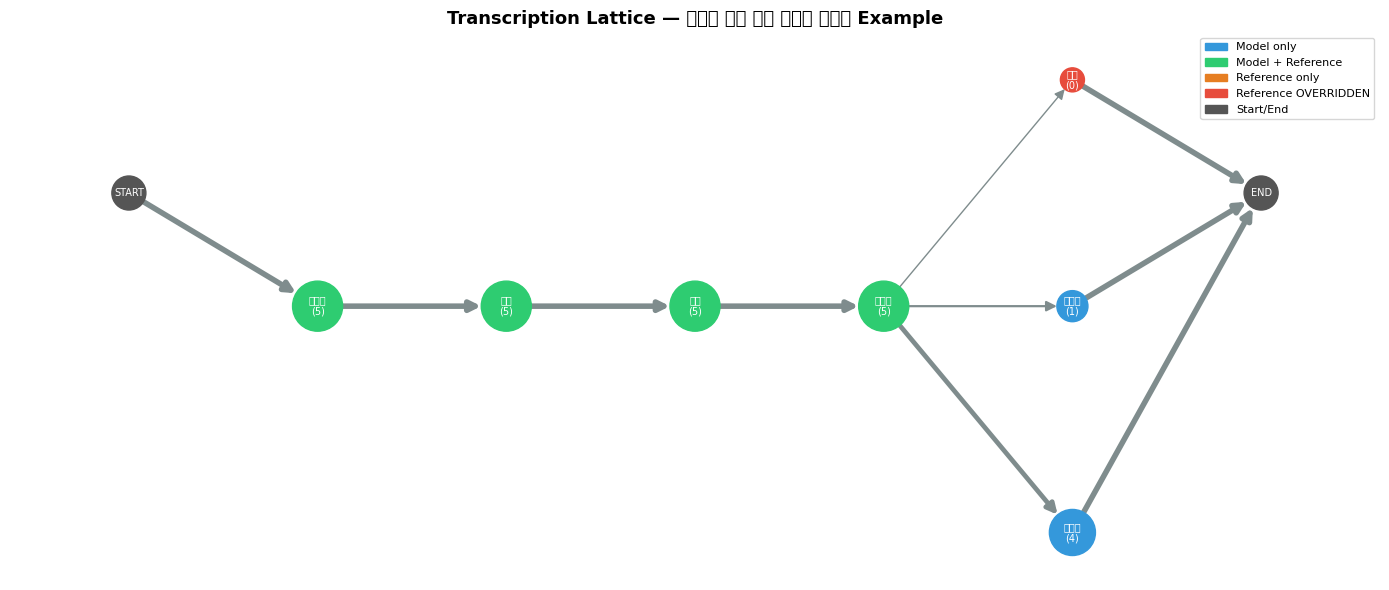

Saved: /content/lattice_visualization.png


In [ ]:
visualize_lattice(lattice, title='Transcription Lattice — मैं घर जा रहा हूँ Example')

## SECTION 9 — Final Comparison Table

In [ ]:
print('\n' + '='*75)
print('  FINAL RESULTS: STANDARD WER vs LATTICE WER')
print('='*75)

display_cols = ['Model', 'Standard_WER', 'Lattice_WER', 'Improvement', 'S', 'D', 'I']
df_display   = df_results[display_cols].copy()
df_display['Standard_WER'] = df_display['Standard_WER'].apply(lambda x: f'{x:.4f}')
df_display['Lattice_WER']  = df_display['Lattice_WER'].apply(lambda x: f'{x:.4f}')
df_display['Improvement']  = df_display['Improvement'].apply(lambda x: f'+{x:.4f}' if x >= 0 else f'{x:.4f}')

print(df_display.to_string(index=False))

print('\n  Reference:       ', REFERENCE)
print('  Effective Ref:   ', df_results.iloc[0]['Effective_Ref'])
print()

print('  INTERPRETATION:')
for _, row in df_results.iterrows():
    hyp_last = row['Hypothesis'].split()[-1]
    ref_last = REFERENCE.split()[-1]
    print(f'  {row["Model"]}: last word="{hyp_last}" vs ref="{ref_last}"')
    if float(row['Standard_WER']) > 0 and float(row['Lattice_WER']) == 0.0:
        print(f'    → Standard penalizes ({row["Standard_WER"]} WER), Lattice does NOT (consensus override)')
    elif float(row['Lattice_WER']) < float(row['Standard_WER']):
        print(f'    → Lattice reduces penalty: {row["Standard_WER"]} → {row["Lattice_WER"]} (orthographic variant or partial consensus)')
    else:
        print(f'    → No change: both agree')

print()
print('  SUMMARY OF FAIRNESS IMPROVEMENT:')
avg_std = df_results['Standard_WER'].mean()
avg_lat = df_results['Lattice_WER'].mean()
print(f'    Avg Standard WER:   {avg_std:.4f}')
print(f'    Avg Lattice WER:    {avg_lat:.4f}')
print(f'    Avg Improvement:    +{avg_std - avg_lat:.4f} ({(avg_std-avg_lat)/avg_std*100 if avg_std>0 else 0:.1f}% reduction)')
print('='*75)


  FINAL RESULTS: STANDARD WER vs LATTICE WER
  Model Standard_WER Lattice_WER Improvement  S  D  I
Model-A       0.2000      0.0000     +0.2000  1  0  0
Model-C       0.2000      0.0000     +0.2000  1  0  0
Model-D       0.2000      0.0000     +0.2000  1  0  0
Model-E       0.2000      0.0000     +0.2000  1  0  0
Model-B       0.2000      0.0200     +0.1800  1  0  0

  Reference:        मैं घर जा रहा हु
  Effective Ref:    मैं घर जा रहा हूँ

  INTERPRETATION:
  Model-A: last word="हूँ" vs ref="हु"
    → Standard penalizes (0.2 WER), Lattice does NOT (consensus override)
  Model-C: last word="हूँ" vs ref="हु"
    → Standard penalizes (0.2 WER), Lattice does NOT (consensus override)
  Model-D: last word="हूँ" vs ref="हु"
    → Standard penalizes (0.2 WER), Lattice does NOT (consensus override)
  Model-E: last word="हूँ" vs ref="हु"
    → Standard penalizes (0.2 WER), Lattice does NOT (consensus override)
  Model-B: last word="हूं" vs ref="हु"
    → Lattice reduces penalty: 0.2 → 0.02 (o

In [ ]:
df_results.to_csv('/content/lattice_wer_results.csv', index=False, encoding='utf-8-sig')
print('Saved: /content/lattice_wer_results.csv')

Saved: /content/lattice_wer_results.csv


## SECTION 10 — Extended Test: Realistic Multi-Error Scenario

In [ ]:
MODEL_OUTPUTS_EXT = {
    'Whisper-S':  'आज मौसम बहुत अच्छा है और हम बाहर जाएंगे',       # mostly correct
    'Whisper-M':  'आज मौसम बहुत अछा है और हम बाहर जाएंगे',         # अछा = misspelling
    'Wav2Vec2':   'आज मौसम बहुत अच्छा हैं और हम बाहर जाएंगे',      # हैं = variant
    'MMS':        'आज का मौसम बहुत अच्छा है और हम बाहर जाएंगे',    # extra 'का'
    'IndicWav2V': 'आज मौसम अच्छा है और हम बाहर जाएंगे',            # missing 'बहुत'
}

REFERENCE_EXT = 'आज मौसम बहुत अच्छा हे और हम बाहर जाएंगे'  # हे = reference error (should be है)

print('Extended test:')
print('Reference:', REFERENCE_EXT)
print()

df_ext, lattice_ext = evaluate_models(
    model_outputs=MODEL_OUTPUTS_EXT,
    reference=REFERENCE_EXT,
    trust_ratio=0.6,
    variant_penalty=0.1,
    verbose=True,
)

print('\n' + '='*75)
print('  EXTENDED EXAMPLE — FINAL COMPARISON TABLE')
print('='*75)
print(df_ext[['Model','Standard_WER','Lattice_WER','Improvement','S','D','I']].to_string(index=False))

Extended test:
Reference: आज मौसम बहुत अच्छा हे और हम बाहर जाएंगे


  LATTICE ANALYSIS
Lattice Summary:
  Positions:          10
  Models:             5
  Trust threshold:    3/5
  Total nodes:        27
  Total edges:        83
  Override positions: []
  Effective ref:      आज मौसम बहुत अच्छा हे और हम बाहर जाएंगे

  Pos 0: ref="आज" | consensus="आज" (5/5) 
         [REF] "आज" ← models: {'MMS', 'IndicWav2V', 'Wav2Vec2', 'Whisper-S', 'Whisper-M'}
  Pos 1: ref="मौसम" | consensus="मौसम" (4/5) 
         [REF] "मौसम" ← models: {'IndicWav2V', 'Wav2Vec2', 'Whisper-S', 'Whisper-M'}
               "का" ← models: {'MMS'}
  Pos 2: ref="बहुत" | consensus="बहुत" (3/5) 
         [REF] "बहुत" ← models: {'Wav2Vec2', 'Whisper-S', 'Whisper-M'}
               "मौसम" ← models: {'MMS'}
               "अच्छा" ← models: {'IndicWav2V'}
  Pos 3: ref="अच्छा" | consensus="अच्छा" (2/5) 
         [REF] "अच्छा" ← models: {'Wav2Vec2', 'Whisper-S'}
               "अछा" ← models: {'Whisper-M'}
               "बहुत" ← m

/tmp/ipykernel_8643/4195737409.py:95: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/lattice_visualization.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8643/4195737409.py:95: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.savefig('/content/lattice_visualization.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8643/4195737409.py:95: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/lattice_visualization.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8643/4195737409.py:95: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/lattice_visualization.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_8643/4195737409.py:95: UserWarning: Glyph 2380 (\N{DEVANAGARI VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/lattice_visualization.png', dpi=150, bbox_

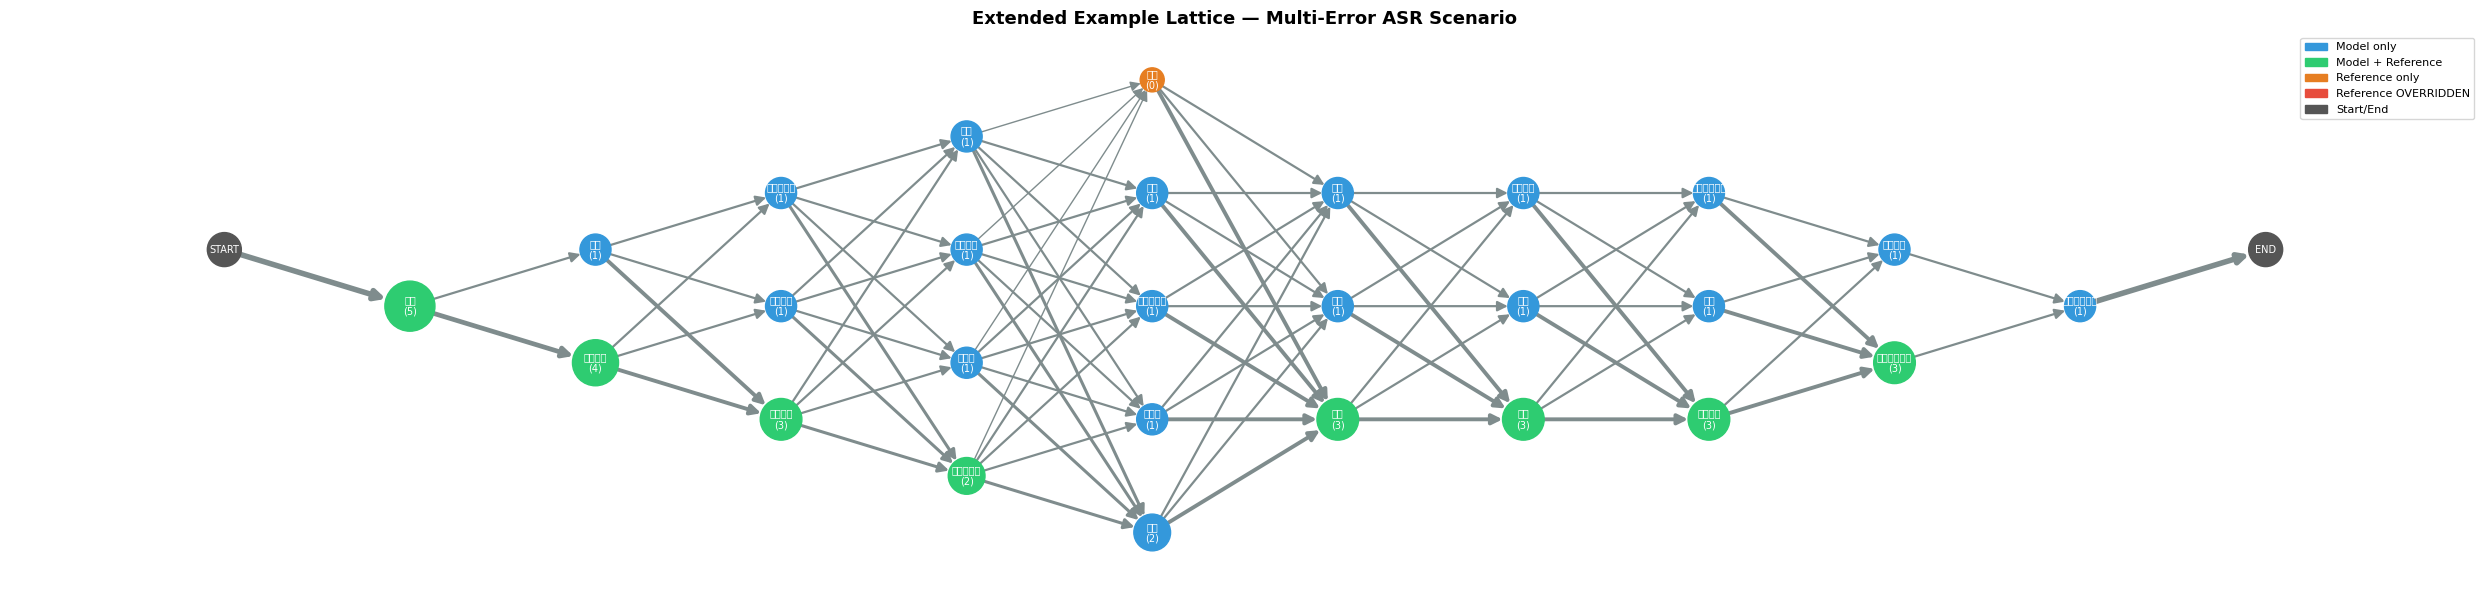

Saved: /content/lattice_visualization.png


In [ ]:
visualize_lattice(lattice_ext, title='Extended Example Lattice — Multi-Error ASR Scenario')

## SECTION 11 — WER Comparison Bar Chart

/tmp/ipykernel_8643/109976009.py:35: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/109976009.py:35: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_8643/109976009.py:35: UserWarning: Glyph 2370 (\N{DEVANAGARI VOWEL SIGN UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/109976009.py:35: UserWarning: Glyph 2305 (\N{DEVANAGARI SIGN CANDRABINDU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/109976009.py:35: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/109976009.py:35: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8643/109976009.py:36: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.savefig('

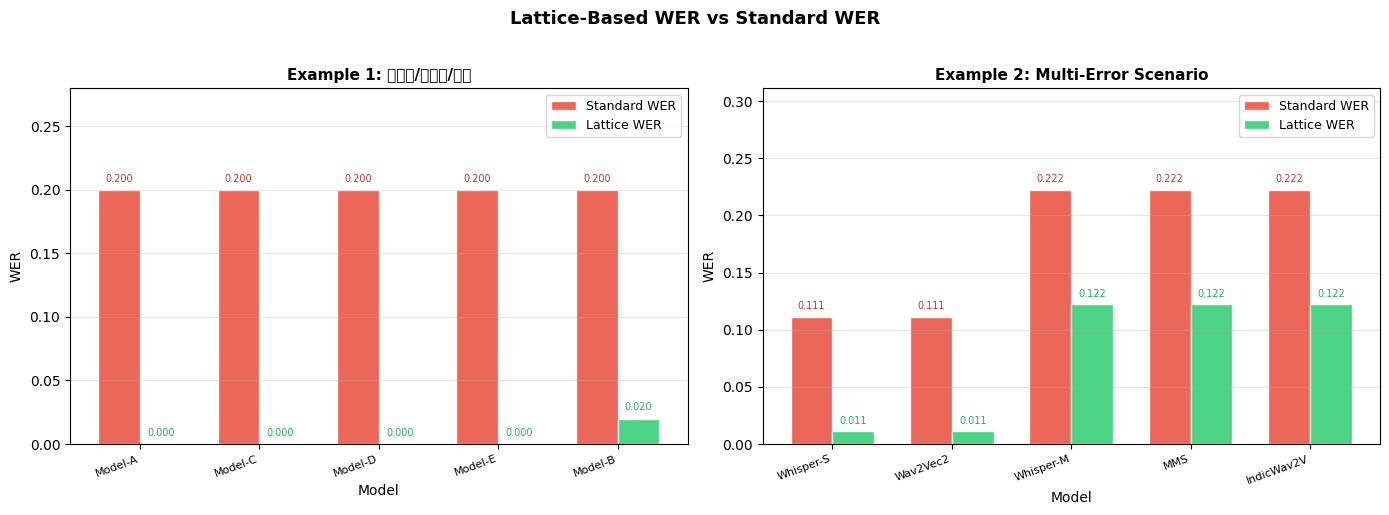

Saved: /content/wer_comparison_chart.png


In [ ]:
def plot_wer_comparison(df: pd.DataFrame, title: str = 'Standard vs Lattice WER'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, df_plot, t in zip(
        axes,
        [df_results, df_ext],
        ['Example 1: हूँ/हूं/हु', 'Example 2: Multi-Error Scenario']
    ):
        models = df_plot['Model']
        x      = np.arange(len(models))
        width  = 0.35

        bars1 = ax.bar(x - width/2, df_plot['Standard_WER'], width, label='Standard WER',
                       color='#e74c3c', alpha=0.85, edgecolor='white')
        bars2 = ax.bar(x + width/2, df_plot['Lattice_WER'],  width, label='Lattice WER',
                       color='#2ecc71', alpha=0.85, edgecolor='white')

        ax.set_xlabel('Model', fontsize=10)
        ax.set_ylabel('WER', fontsize=10)
        ax.set_title(t, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha='right', fontsize=8)
        ax.legend(fontsize=9)
        ax.set_ylim(0, max(df_plot['Standard_WER'].max(), 0.01) * 1.4)
        ax.grid(axis='y', alpha=0.3)

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, color='#c0392b')
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, color='#27ae60')

    plt.suptitle('Lattice-Based WER vs Standard WER', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/content/wer_comparison_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: /content/wer_comparison_chart.png')

plot_wer_comparison(df_results)

## SECTION 12 — Integration with Q1/Q2 ASR Pipeline

In [ ]:
def batch_lattice_evaluation(
    model_hyp_dict: Dict[str, List[str]],
    references: List[str],
    trust_ratio: float = 0.6,
) -> pd.DataFrame:
    """
    Evaluate multiple models over a corpus.

    Args:
        model_hyp_dict: {model_id: [hyp1, hyp2, ...]}
        references:     [ref1, ref2, ...]

    Returns:
        DataFrame with per-model aggregate standard and lattice WER.
    """
    assert all(len(v) == len(references) for v in model_hyp_dict.values()), \
        'All models must have same number of hypotheses as references'

    n_samples    = len(references)
    model_ids    = list(model_hyp_dict.keys())
    std_totals   = {mid: {'S': 0, 'D': 0, 'I': 0, 'N': 0} for mid in model_ids}
    lat_costs    = {mid: 0.0 for mid in model_ids}
    lat_N_totals = {mid: 0   for mid in model_ids}

    for i in range(n_samples):
        sample_outputs = {mid: model_hyp_dict[mid][i] for mid in model_ids}
        ref = references[i]

        for mid in model_ids:
            sw = compute_standard_wer(sample_outputs[mid], ref)
            std_totals[mid]['S'] += sw['S']
            std_totals[mid]['D'] += sw['D']
            std_totals[mid]['I'] += sw['I']
            std_totals[mid]['N'] += sw['N']

        lattice = TranscriptionLattice(n_models=len(model_ids), trust_ratio=trust_ratio)
        for mid, hyp in sample_outputs.items():
            lattice.add_hypothesis(mid, tokenize(hyp))
        lattice.add_reference(tokenize(ref))
        lattice.build()

        for mid in model_ids:
            lw = compute_lattice_wer(sample_outputs[mid], lattice)
            lat_costs[mid]    += lw['total_cost']
            lat_N_totals[mid] += lw['N']

    rows = []
    for mid in model_ids:
        st  = std_totals[mid]
        N   = st['N']
        std_wer = (st['S'] + st['D'] + st['I']) / N if N > 0 else 0
        lat_wer = lat_costs[mid] / lat_N_totals[mid] if lat_N_totals[mid] > 0 else 0
        rows.append({
            'Model':       mid,
            'Standard_WER': round(std_wer, 4),
            'Lattice_WER':  round(lat_wer, 4),
            'Improvement':  round(std_wer - lat_wer, 4),
            'Total_S': st['S'], 'Total_D': st['D'], 'Total_I': st['I'],
            'N_words': N,
        })

    return pd.DataFrame(rows).sort_values('Lattice_WER').reset_index(drop=True)


demo_refs  = [
    'मैं घर जा रहा हु',
    'आज मौसम बहुत अच्छा हे',
    'वह स्कूल नहि गया',
]
demo_hyps  = {
    'Whisper-S': [
        'मैं घर जा रहा हूँ',
        'आज मौसम बहुत अच्छा है',
        'वह स्कूल नहीं गया',
    ],
    'Whisper-M': [
        'मैं घर जा रहा हूं',
        'आज मौसम बहुत अछा है',
        'वह स्कूल नहीं गया',
    ],
    'Wav2Vec2': [
        'मैं घर रहा हूँ',
        'आज मौसम अच्छा है',
        'वह स्कूल नहीं गया था',
    ],
    'MMS': [
        'मैं घर जा रहा हूँ',
        'आज का मौसम बहुत अच्छा है',
        'वह स्कूल नहीं गया',
    ],
    'IndicASR': [
        'मैं घर जा रहा हूँ',
        'आज मौसम बहुत अच्छा है',
        'वह स्कूल नहीं गया',
    ],
}

df_batch = batch_lattice_evaluation(demo_hyps, demo_refs, trust_ratio=0.6)
print('\n' + '='*65)
print('  BATCH EVALUATION — CORPUS-LEVEL WER')
print('='*65)
print(df_batch.to_string(index=False))


  BATCH EVALUATION — CORPUS-LEVEL WER
    Model  Standard_WER  Lattice_WER  Improvement  Total_S  Total_D  Total_I  N_words
Whisper-S        0.2143       0.0000       0.2143        3        0        0       14
 IndicASR        0.2143       0.0000       0.2143        3        0        0       14
      MMS        0.2857       0.0714       0.2143        3        0        1       14
Whisper-M        0.2857       0.0786       0.2071        4        0        0       14
 Wav2Vec2        0.4286       0.2143       0.2143        3        2        1       14


In [ ]:
df_ext.to_csv('/content/lattice_wer_extended.csv',   index=False, encoding='utf-8-sig')
df_batch.to_csv('/content/lattice_wer_batch.csv',    index=False, encoding='utf-8-sig')
df_results.to_csv('/content/lattice_wer_results.csv',index=False, encoding='utf-8-sig')

print('='*60)
print('  ALL OUTPUT FILES SAVED')
print('='*60)
print('  /content/lattice_wer_results.csv       (Example 1)')
print('  /content/lattice_wer_extended.csv      (Example 2)')
print('  /content/lattice_wer_batch.csv         (Batch corpus)')
print('  /content/lattice_visualization.png     (Lattice DAG)')
print('  /content/wer_comparison_chart.png      (Bar chart)')
print()
print('  KEY DESIGN PARAMETERS (tunable):')
print('    trust_ratio     = 0.6  → 3/5 models to override reference')
print('    variant_penalty = 0.1  → 10% cost for orthographic variants')
print('    MAX_EDIT_DIST          → set in spelling pipeline')
print()
print('  FURTHER IMPROVEMENTS:')
print('    1. Use acoustic confidence scores as edge weights (not just counts)')
print('    2. Replace word-level DP with CTC lattice from model beams')
print('    3. Add language model re-scoring on lattice paths (KenLM/BERT)')
print('    4. Use SCTK sclite for TRS-level alignment instead of DP')
print('    5. Cluster phonetically similar words (Soundex-Devanagari)')
print('='*60)

  ALL OUTPUT FILES SAVED
  /content/lattice_wer_results.csv       (Example 1)
  /content/lattice_wer_extended.csv      (Example 2)
  /content/lattice_wer_batch.csv         (Batch corpus)
  /content/lattice_visualization.png     (Lattice DAG)
  /content/wer_comparison_chart.png      (Bar chart)

  KEY DESIGN PARAMETERS (tunable):
    trust_ratio     = 0.6  → 3/5 models to override reference
    variant_penalty = 0.1  → 10% cost for orthographic variants
    MAX_EDIT_DIST          → set in spelling pipeline

  FURTHER IMPROVEMENTS:
    1. Use acoustic confidence scores as edge weights (not just counts)
    2. Replace word-level DP with CTC lattice from model beams
    3. Add language model re-scoring on lattice paths (KenLM/BERT)
    4. Use SCTK sclite for TRS-level alignment instead of DP
    5. Cluster phonetically similar words (Soundex-Devanagari)
